# 🚗 Indian Road Accident Analysis & 2026 Prediction (2022–2025)
### Best accuracy possible | All charts shown inline + saved to outputs/
---

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — Install & Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import subprocess, sys
for pkg in ['xgboost','lightgbm','imbalanced-learn','shap']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.metrics            import (accuracy_score, f1_score, classification_report,
                                        confusion_matrix, precision_recall_fscore_support)
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.neighbors          import KNeighborsClassifier
from xgboost                    import XGBClassifier
from lightgbm                   import LGBMClassifier
from imblearn.over_sampling     import SMOTE
import shap

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa','figure.dpi':110})
COLORS    = ['#2ecc71','#e67e22','#e74c3c']
SEV_ORDER = ['minor','major','fatal']
SEED      = 42
np.random.seed(SEED)

def save_and_show(filename):
    plt.savefig(f'outputs/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Saved -> outputs/{filename}')

print('✅ All libraries loaded')

✅ All libraries loaded


In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — Load & Filter 2022-2025
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv('indian_roads_dataset.csv', parse_dates=['date'])
df = df[df['date'].dt.year.between(2022, 2025)].copy()
df['year']     = df['date'].dt.year
df['month']    = df['date'].dt.month
df['festival'] = df['festival'].fillna('None')

print(f'Shape        : {df.shape}')
print(f'Date range   : {df.date.min().date()} to {df.date.max().date()}')
print(f'\nTarget distribution:')
vc = df['accident_severity'].value_counts()
for k, v in vc.items():
    print(f'  {k:<8} {v:>6}  ({v/len(df)*100:.1f}%)')

Shape        : (20000, 26)
Date range   : 2022-01-01 to 2025-04-15

Target distribution:
  minor     11025  (55.1%)
  major      5988  (29.9%)
  fatal      2987  (14.9%)


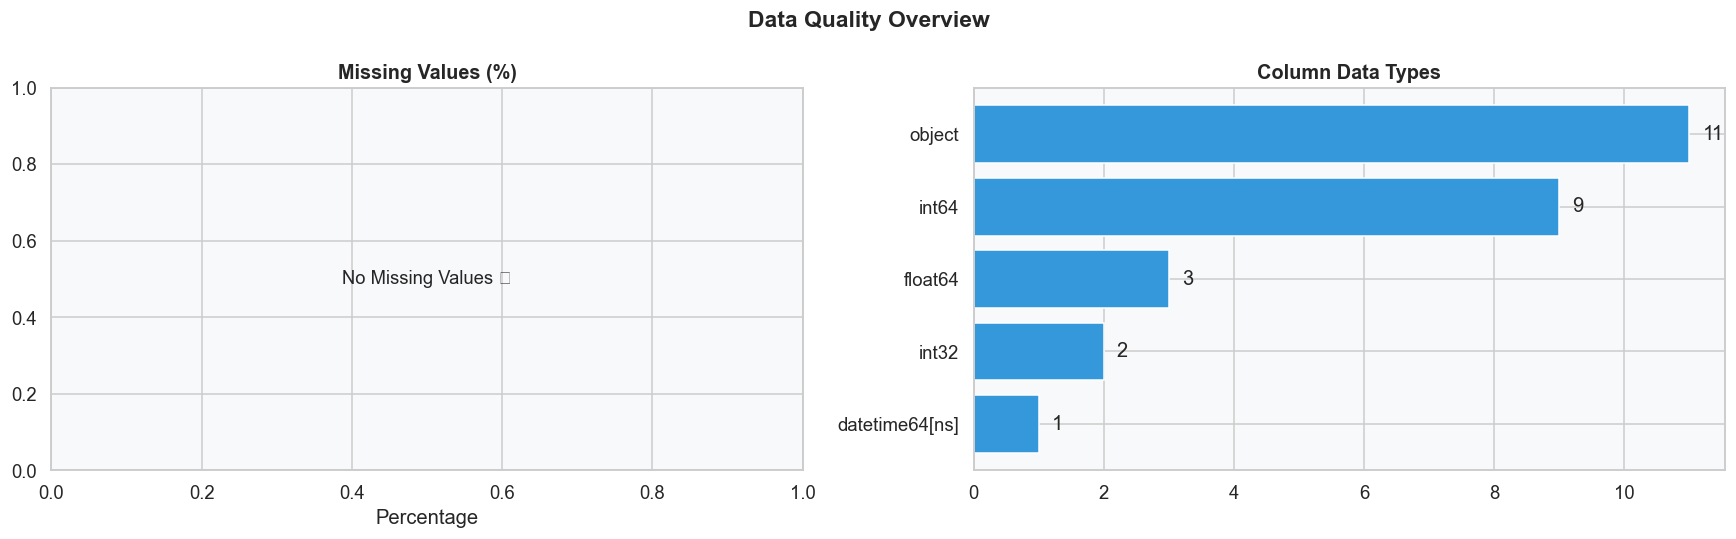

💾 Saved -> outputs/01_data_quality.png


In [42]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Data Quality (IMPROVED)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Missing values ─────────────────────────────
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)

# 🔥 Keep only columns with missing values
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=True)

ax = axes[0]

if len(miss_pct) > 0:
    bars = ax.barh(miss_pct.index, miss_pct.values, color='#e74c3c')

    for bar, val in zip(bars, miss_pct.values):
        ax.text(bar.get_width()+0.5,
                bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%',
                va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'No Missing Values 🎉', ha='center', va='center', fontsize=12)

ax.set_title('Missing Values (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage')

# ── Data types (bar instead of pie) ────────────
dtype_counts = df.dtypes.astype(str).value_counts().sort_values()

axes[1].barh(dtype_counts.index, dtype_counts.values, color='#3498db')
axes[1].set_title('Column Data Types', fontsize=13, fontweight='bold')

for i, v in enumerate(dtype_counts.values):
    axes[1].text(v + 0.2, i, str(v), va='center')

# ── Layout ─────────────────────────────────────
plt.suptitle('Data Quality Overview', fontsize=15, fontweight='bold')
plt.tight_layout()

save_and_show('01_data_quality.png')

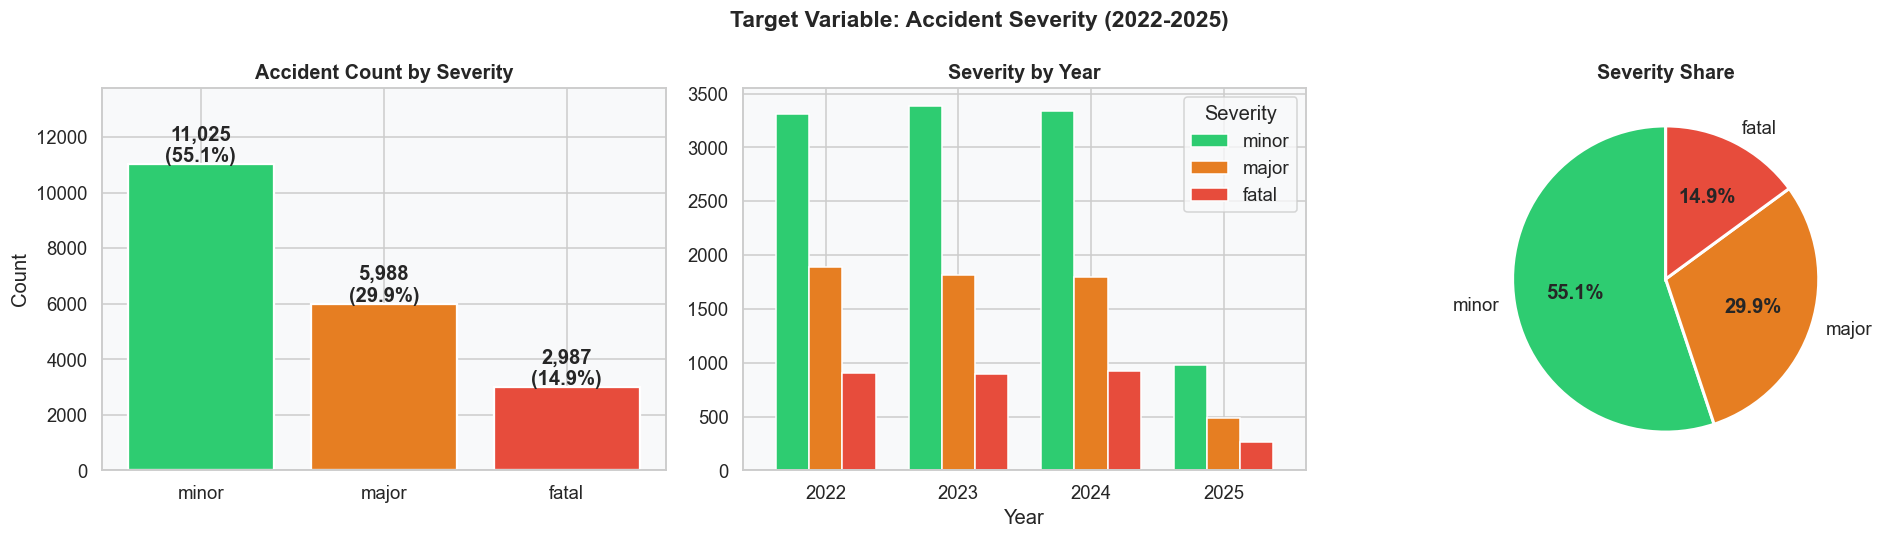

💾 Saved -> outputs/02_target_distribution.png


In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — Target Variable Analysis
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
sev_counts = df['accident_severity'].value_counts().reindex(SEV_ORDER)
fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
bars = axes[0].bar(sev_counts.index, sev_counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sev_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Accident Count by Severity', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, sev_counts.max()*1.25)
yearly = df.groupby(['year','accident_severity']).size().unstack().reindex(columns=SEV_ORDER)
yearly.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='white', width=0.75)
axes[1].set_title('Severity by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Severity')
wedges, texts, autotexts = axes[2].pie(
    sev_counts.values, labels=sev_counts.index, colors=COLORS,
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontweight('bold')
axes[2].set_title('Severity Share', fontsize=13, fontweight='bold')
plt.suptitle('Target Variable: Accident Severity (2022-2025)', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('02_target_distribution.png')

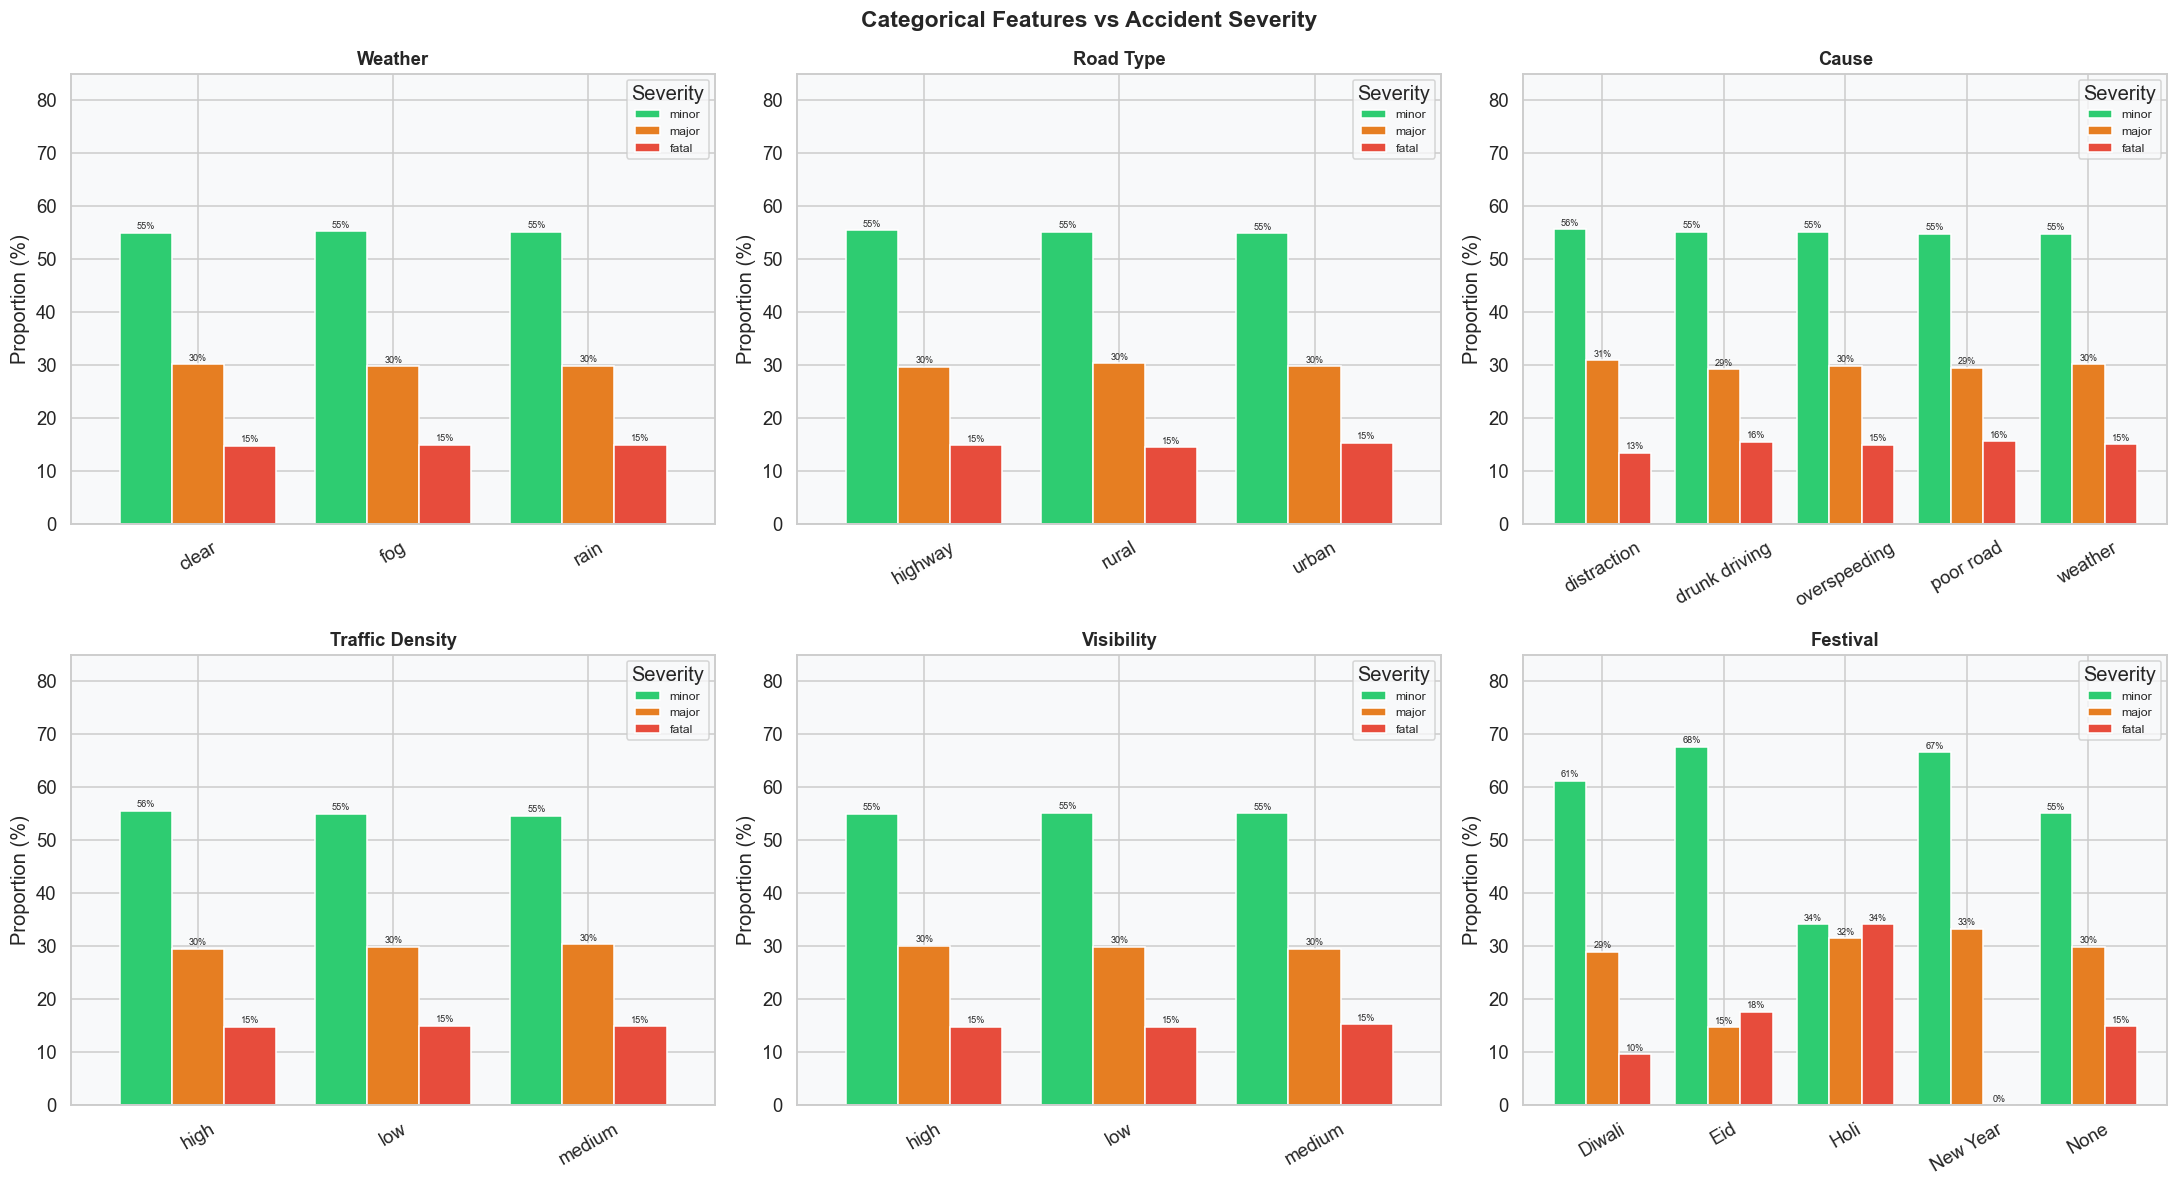

💾 Saved -> outputs/03_categorical_vs_severity.png


In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — Categorical Features vs Severity
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cats = [('weather','Weather'),('road_type','Road Type'),('cause','Cause'),
        ('traffic_density','Traffic Density'),('visibility','Visibility'),('festival','Festival')]
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, (col, title) in zip(axes.flat, cats):
    ct = pd.crosstab(df[col], df['accident_severity'], normalize='index')[SEV_ORDER]*100
    ct.plot(kind='bar', ax=ax, color=COLORS, edgecolor='white', width=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Proportion (%)')
    ax.tick_params(axis='x', rotation=30); ax.legend(title='Severity', fontsize=8); ax.set_ylim(0, 85)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', fontsize=6, padding=1)
plt.suptitle('Categorical Features vs Accident Severity', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('03_categorical_vs_severity.png')

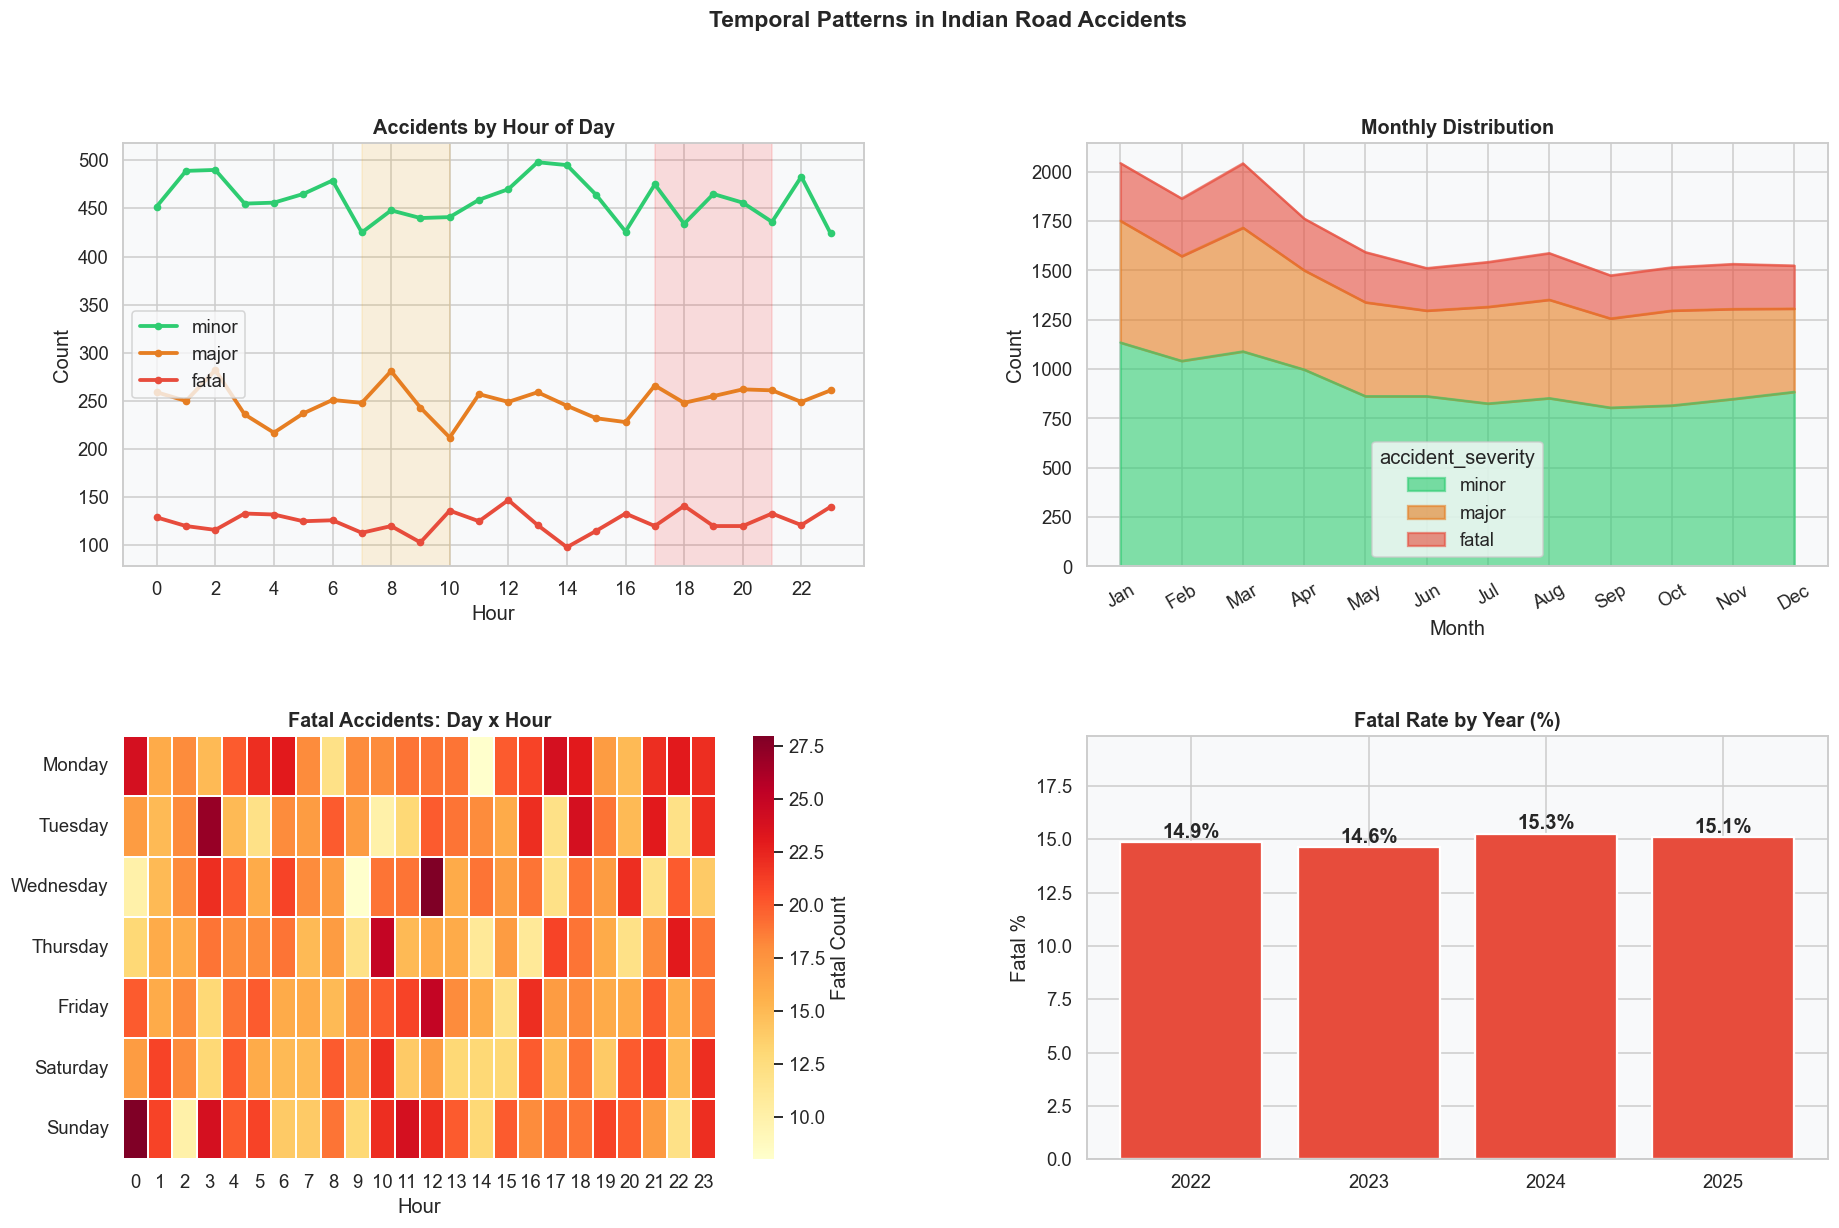

💾 Saved -> outputs/04_temporal_patterns.png


In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Temporal Patterns
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])
hourly = df.groupby(['hour','accident_severity']).size().unstack()[SEV_ORDER]
hourly.plot(ax=ax1, color=COLORS, linewidth=2.5, marker='o', markersize=4)
ax1.axvspan(7,10,alpha=0.12,color='orange'); ax1.axvspan(17,21,alpha=0.12,color='red')
ax1.set_title('Accidents by Hour of Day', fontsize=13, fontweight='bold')
ax1.set_xlabel('Hour'); ax1.set_ylabel('Count'); ax1.set_xticks(range(0,24,2)); ax1.legend()
ax2 = fig.add_subplot(gs[0, 1])
monthly = df.groupby(['month','accident_severity']).size().unstack()[SEV_ORDER]
monthly.plot(ax=ax2, kind='area', color=COLORS, alpha=0.6, linewidth=1.5)
ax2.set_title('Monthly Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month'); ax2.set_ylabel('Count'); ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],rotation=30)
ax3 = fig.add_subplot(gs[1, 0])
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df[df['accident_severity']=='fatal'].groupby(['day_of_week','hour']).size().unstack(fill_value=0)
pivot = pivot.reindex([d for d in day_order if d in pivot.index])
sns.heatmap(pivot, ax=ax3, cmap='YlOrRd', linewidths=0.2, cbar_kws={'label':'Fatal Count'})
ax3.set_title('Fatal Accidents: Day x Hour', fontsize=13, fontweight='bold')
ax3.set_xlabel('Hour'); ax3.set_ylabel('')
ax4 = fig.add_subplot(gs[1, 1])
yr = df.groupby(['year','accident_severity']).size().unstack()
yr['fatal_%'] = yr['fatal']/yr.sum(axis=1)*100
bars = ax4.bar(yr.index.astype(str), yr['fatal_%'], color='#e74c3c', edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, yr['fatal_%']):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}%', ha='center', fontweight='bold')
ax4.set_title('Fatal Rate by Year (%)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Fatal %'); ax4.set_ylim(0, yr['fatal_%'].max()*1.3)
plt.suptitle('Temporal Patterns in Indian Road Accidents', fontsize=15, fontweight='bold')
save_and_show('04_temporal_patterns.png')

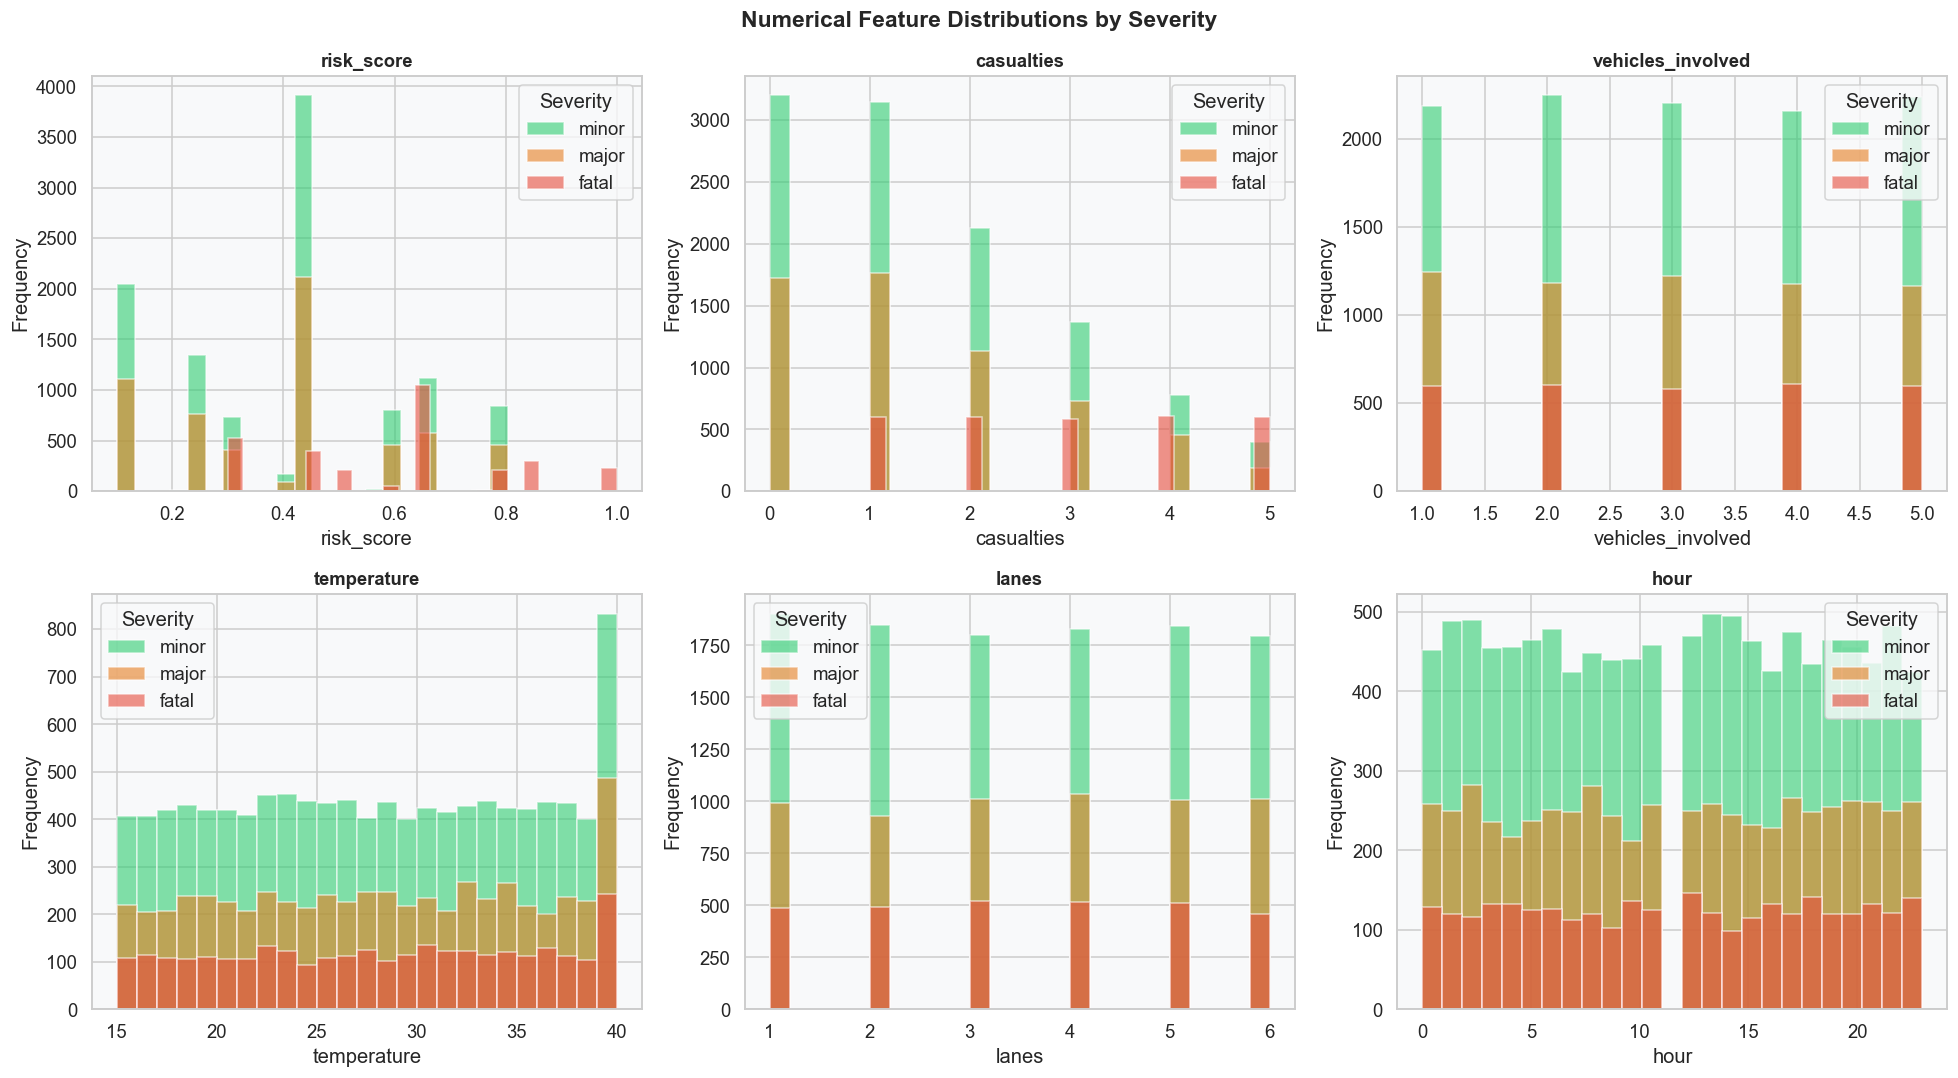

💾 Saved -> outputs/05_numerical_distributions.png


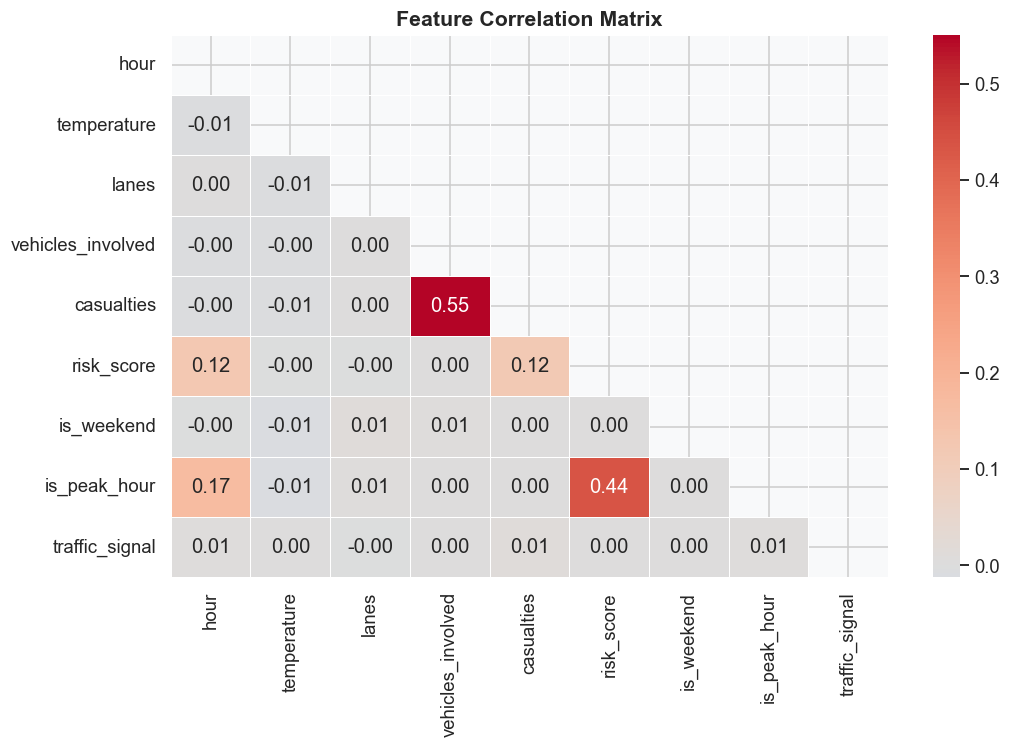

💾 Saved -> outputs/06_correlation_matrix.png


In [27]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — Numerical Distributions & Correlation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
num_cols = ['risk_score','casualties','vehicles_involved','temperature','lanes','hour']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, num_cols):
    for sev, color in zip(SEV_ORDER, COLORS):
        ax.hist(df[df['accident_severity']==sev][col], bins=25, alpha=0.6, color=color, label=sev, edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold'); ax.set_xlabel(col); ax.set_ylabel('Frequency'); ax.legend(title='Severity')
plt.suptitle('Numerical Feature Distributions by Severity', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('05_numerical_distributions.png')

fig, ax = plt.subplots(figsize=(10, 7))
corr_cols = ['hour','temperature','lanes','vehicles_involved','casualties','risk_score','is_weekend','is_peak_hour','traffic_signal']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
save_and_show('06_correlation_matrix.png')

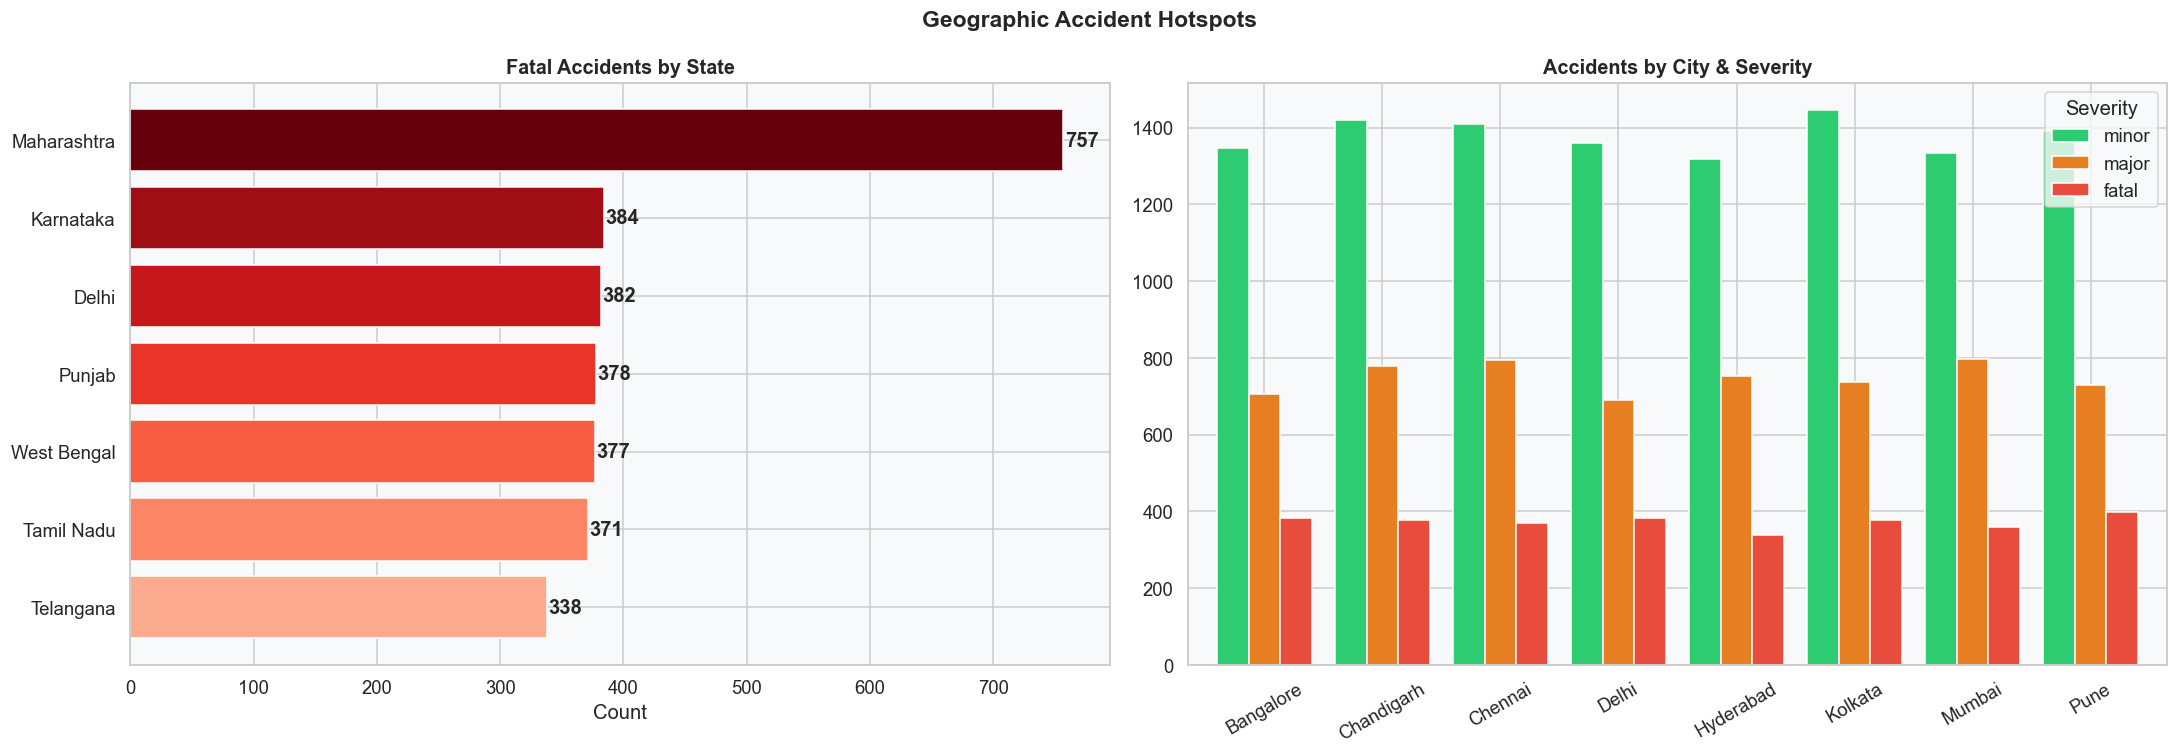

💾 Saved -> outputs/07_geographic_hotspots.png


In [28]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — Geographic Hotspots
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
state_fatal = df[df['accident_severity']=='fatal'].groupby('state').size().sort_values()
colors_g = plt.cm.Reds(np.linspace(0.3, 1.0, len(state_fatal)))
axes[0].barh(state_fatal.index, state_fatal.values, color=colors_g)
axes[0].set_title('Fatal Accidents by State', fontsize=13, fontweight='bold'); axes[0].set_xlabel('Count')
for i, v in enumerate(state_fatal.values): axes[0].text(v+1, i, str(v), va='center', fontweight='bold')
city_sev = df.groupby(['city','accident_severity']).size().unstack()[SEV_ORDER]
city_sev.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='white', width=0.8)
axes[1].set_title('Accidents by City & Severity', fontsize=13, fontweight='bold')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=30); axes[1].legend(title='Severity')
plt.suptitle('Geographic Accident Hotspots', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('07_geographic_hotspots.png')

In [29]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — Feature Engineering
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_fe = df.copy()
df_fe['hour_sin']              = np.sin(2*np.pi*df_fe['hour']/24)
df_fe['hour_cos']              = np.cos(2*np.pi*df_fe['hour']/24)
df_fe['month_sin']             = np.sin(2*np.pi*df_fe['month']/12)
df_fe['month_cos']             = np.cos(2*np.pi*df_fe['month']/12)
df_fe['is_night']              = ((df_fe['hour']>=20)|(df_fe['hour']<=5)).astype(int)
df_fe['casualties_per_vehicle']= (df_fe['casualties']/(df_fe['vehicles_involved'].clip(lower=1))).round(3)
df_fe['high_risk']             = (df_fe['risk_score']>=0.7).astype(int)
df_fe['is_festival']           = (df_fe['festival']!='None').astype(int)
df_fe['risk_x_cas']            = df_fe['risk_score'] * df_fe['casualties']
df_fe['risk_squared']          = df_fe['risk_score'] ** 2
# Key risk threshold bins — very predictive based on EDA
df_fe['rs_very_high']          = (df_fe['risk_score'] > 0.82).astype(int)
df_fe['rs_high']               = df_fe['risk_score'].between(0.64, 0.82).astype(int)
df_fe['rs_low']                = (df_fe['risk_score'] < 0.28).astype(int)
# Interaction features
df_fe['night_fog']             = ((df_fe['is_night']==1)&(df_fe['weather']=='fog')).astype(int)
df_fe['highway_fast']          = ((df_fe['road_type']=='highway')&(df_fe['cause']=='overspeeding')).astype(int)
df_fe['drunk_night']           = ((df_fe['is_night']==1)&(df_fe['cause']=='drunk driving')).astype(int)
df_fe['high_cas_highway']      = ((df_fe['casualties']>=3)&(df_fe['road_type']=='highway')).astype(int)

cat_cols = ['road_type','weather','cause','traffic_density','visibility','day_of_week','city','state']
df_enc   = pd.get_dummies(df_fe, columns=cat_cols, drop_first=False)
le = LabelEncoder()
df_enc['target'] = le.fit_transform(df_fe['accident_severity'])
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

drop_cols = ['accident_id','date','time','accident_severity','festival','year','month','hour']
feat_cols = [c for c in df_enc.columns if c not in drop_cols+['target']]
X = df_enc[feat_cols].astype(float)
y = df_enc['target']
print(f'Feature matrix : {X.shape}')
print(f'\nTop features correlated with target:')
c = X.copy(); c['target'] = y.values
print(c.corr()['target'].abs().sort_values(ascending=False).head(10).to_string())

Label mapping: {'fatal': np.int64(0), 'major': np.int64(1), 'minor': np.int64(2)}
Feature matrix : (20000, 66)

Top features correlated with target:
target                    1.000000
risk_x_cas                0.383625
casualties_per_vehicle    0.348810
rs_very_high              0.309574
casualties                0.284972
risk_squared              0.279201
risk_score                0.259477
rs_low                    0.198028
rs_high                   0.168856
high_risk                 0.160727


Train (raw)  : [2390 4790 8820]
Train (SMOTE): [8820 8820 8820]
Test         : [ 597 1198 2205]


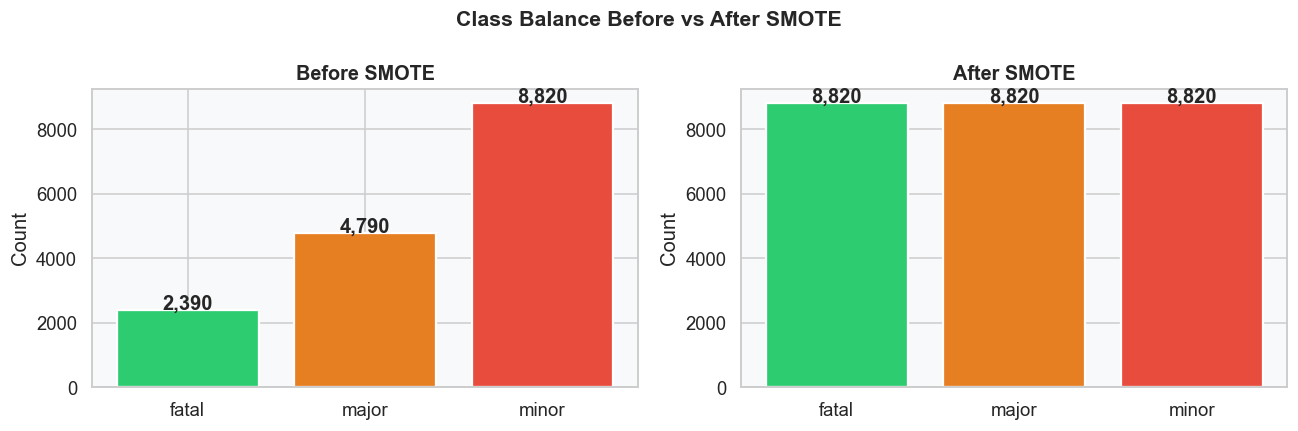

💾 Saved -> outputs/08_smote_balance.png


In [30]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — Split, Scale, SMOTE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_s, y_train)
print(f'Train (raw)  : {np.bincount(y_train)}')
print(f'Train (SMOTE): {np.bincount(y_train_sm)}')
print(f'Test         : {np.bincount(y_test)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(axes,
        [np.bincount(y_train), np.bincount(y_train_sm)],
        ['Before SMOTE','After SMOTE']):
    bars = ax.bar(le.classes_, counts, color=COLORS, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{v:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold'); ax.set_ylabel('Count')
plt.suptitle('Class Balance Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
save_and_show('08_smote_balance.png')

In [31]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — Train All Models
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GPU_MODELS = ['XGBoost (GPU)', 'LightGBM (GPU)']
SKIP_CV    = ['Gradient Boosting','Random Forest','KNN']

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, C=1.0, random_state=SEED, n_jobs=-1, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=15, min_samples_split=5, min_samples_leaf=2,
        random_state=SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=3, min_samples_leaf=1,
        n_jobs=-1, random_state=SEED, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=SEED),
    'XGBoost (GPU)': XGBClassifier(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        tree_method='hist', device='cuda',
        eval_metric='mlogloss', random_state=SEED, verbosity=0),
    'LightGBM (GPU)': LGBMClassifier(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, num_leaves=127,
        reg_alpha=0.1, reg_lambda=1.0,
        device='gpu', random_state=SEED, verbose=-1, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}

results = {}
print(f'{"Model":<22} {"Accuracy":>10} {"F1-Macro":>10} {"CV-F1":>10} {"Time":>8} {"Device":>8}')
print('─'*73)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test_s)
    elapsed = round(time.time()-t0, 2)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    if name in SKIP_CV:
        cv_mean, cv_std = f1, 0.0
    else:
        cv = cross_val_score(model, X_train_sm, y_train_sm,
            cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
            scoring='f1_macro', n_jobs=-1)
        cv_mean, cv_std = cv.mean(), cv.std()
    device = '🔥 GPU' if name in GPU_MODELS else '💻 CPU'
    results[name] = dict(model=model, y_pred=y_pred, accuracy=acc,
                         f1_macro=f1, cv_mean=cv_mean, cv_std=cv_std,
                         train_time=elapsed, device=device)
    print(f'{name:<22} {acc*100:>9.2f}% {f1*100:>9.2f}% {cv_mean*100:>9.2f}% {elapsed:>7}s  {device}')

best_name  = max(results, key=lambda k: results[k]['f1_macro'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']
print(f'\n🏆 Best: {best_name}  Acc={results[best_name]["accuracy"]*100:.2f}%  F1={results[best_name]["f1_macro"]*100:.2f}%')

Model                    Accuracy   F1-Macro      CV-F1     Time   Device
─────────────────────────────────────────────────────────────────────────
Logistic Regression        58.13%     66.30%     67.39%    1.04s  💻 CPU
Decision Tree              63.42%     65.25%     76.15%    0.36s  💻 CPU
Random Forest              67.97%     62.15%     62.15%    4.31s  💻 CPU
Gradient Boosting          67.22%     62.11%     62.11%  209.12s  💻 CPU
XGBoost (GPU)              66.35%     63.50%     79.44%    23.1s  🔥 GPU
LightGBM (GPU)             65.67%     63.96%     79.09%   19.92s  🔥 GPU
KNN                        45.77%     47.85%     47.85%    0.16s  💻 CPU

🏆 Best: Logistic Regression  Acc=58.13%  F1=66.30%


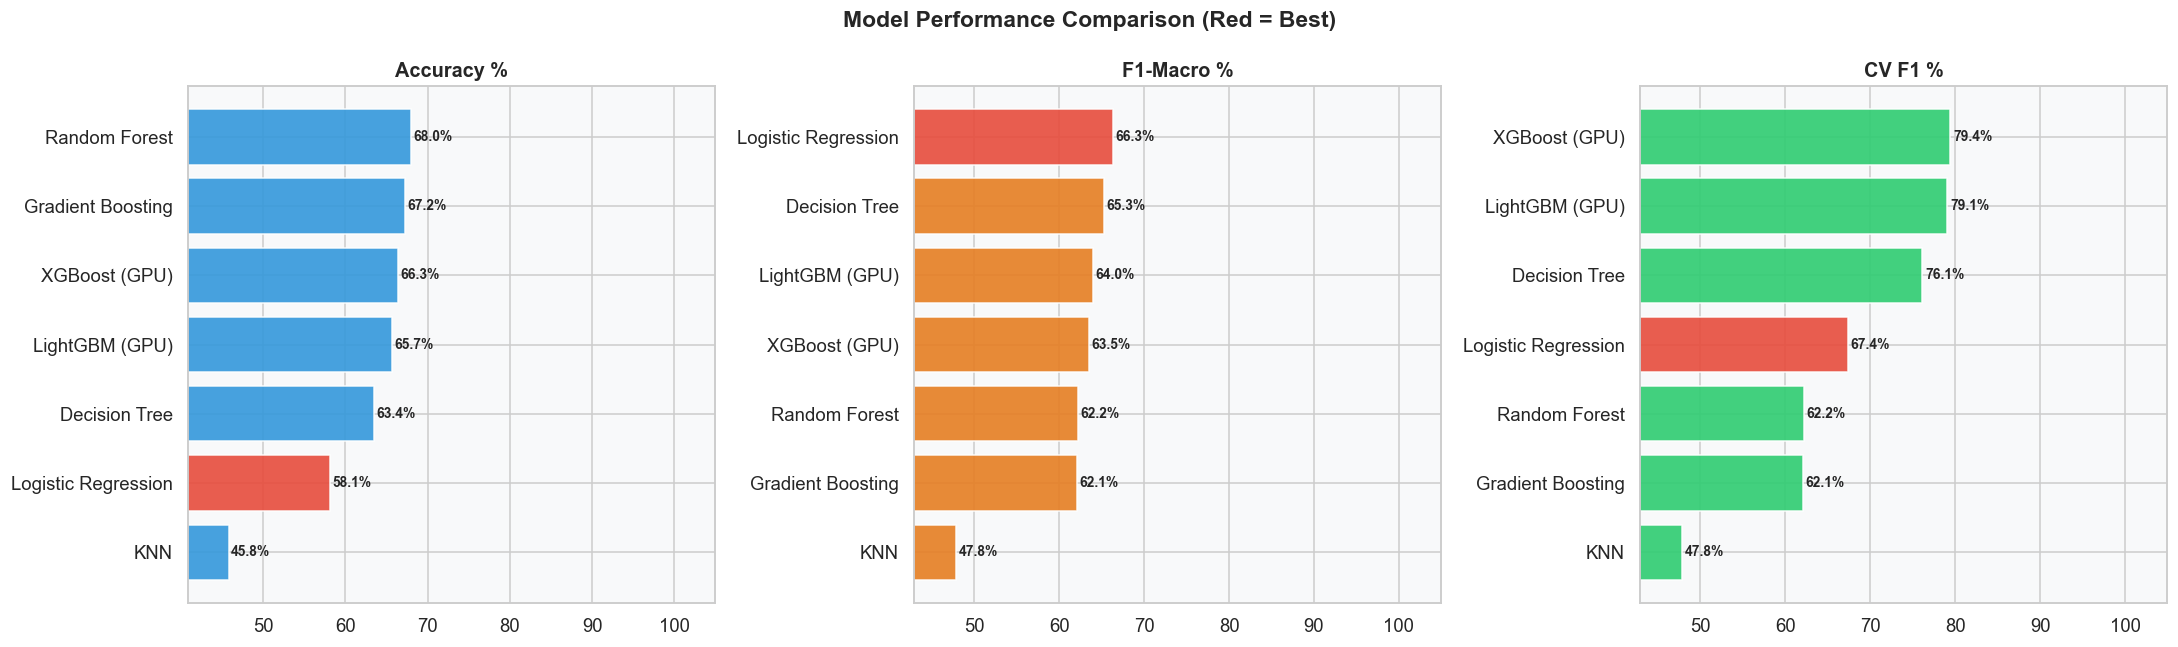

💾 Saved -> outputs/09_model_comparison.png

Leaderboard:
              Model  Accuracy %  F1-Macro %   CV F1 %  Time(s) Device
Logistic Regression      58.125   66.295690 67.394733     1.04  💻 CPU
      Decision Tree      63.425   65.252230 76.147878     0.36  💻 CPU
     LightGBM (GPU)      65.675   63.963422 79.093489    19.92  🔥 GPU
      XGBoost (GPU)      66.350   63.504428 79.441327    23.10  🔥 GPU
      Random Forest      67.975   62.152257 62.152257     4.31  💻 CPU
  Gradient Boosting      67.225   62.112989 62.112989   209.12  💻 CPU
                KNN      45.775   47.846613 47.846613     0.16  💻 CPU


In [32]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — Model Comparison Dashboard
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
res_df = pd.DataFrame([
    {'Model':k,'Accuracy %':v['accuracy']*100,'F1-Macro %':v['f1_macro']*100,
     'CV F1 %':v['cv_mean']*100,'Time(s)':v['train_time'],'Device':v['device']}
    for k,v in results.items()
]).sort_values('F1-Macro %', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (metric, color) in zip(axes, [('Accuracy %','#3498db'),('F1-Macro %','#e67e22'),('CV F1 %','#2ecc71')]):
    sdf  = res_df.sort_values(metric)
    clrs = ['#e74c3c' if n==best_name else color for n in sdf['Model']]
    bars = ax.barh(sdf['Model'], sdf[metric], color=clrs, edgecolor='white', alpha=0.9)
    ax.set_title(metric, fontsize=13, fontweight='bold'); ax.set_xlim(sdf[metric].min()-5, 105)
    for bar, val in zip(bars, sdf[metric]):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
plt.suptitle('Model Performance Comparison (Red = Best)', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('09_model_comparison.png')
print('\nLeaderboard:')
print(res_df.to_string(index=False))

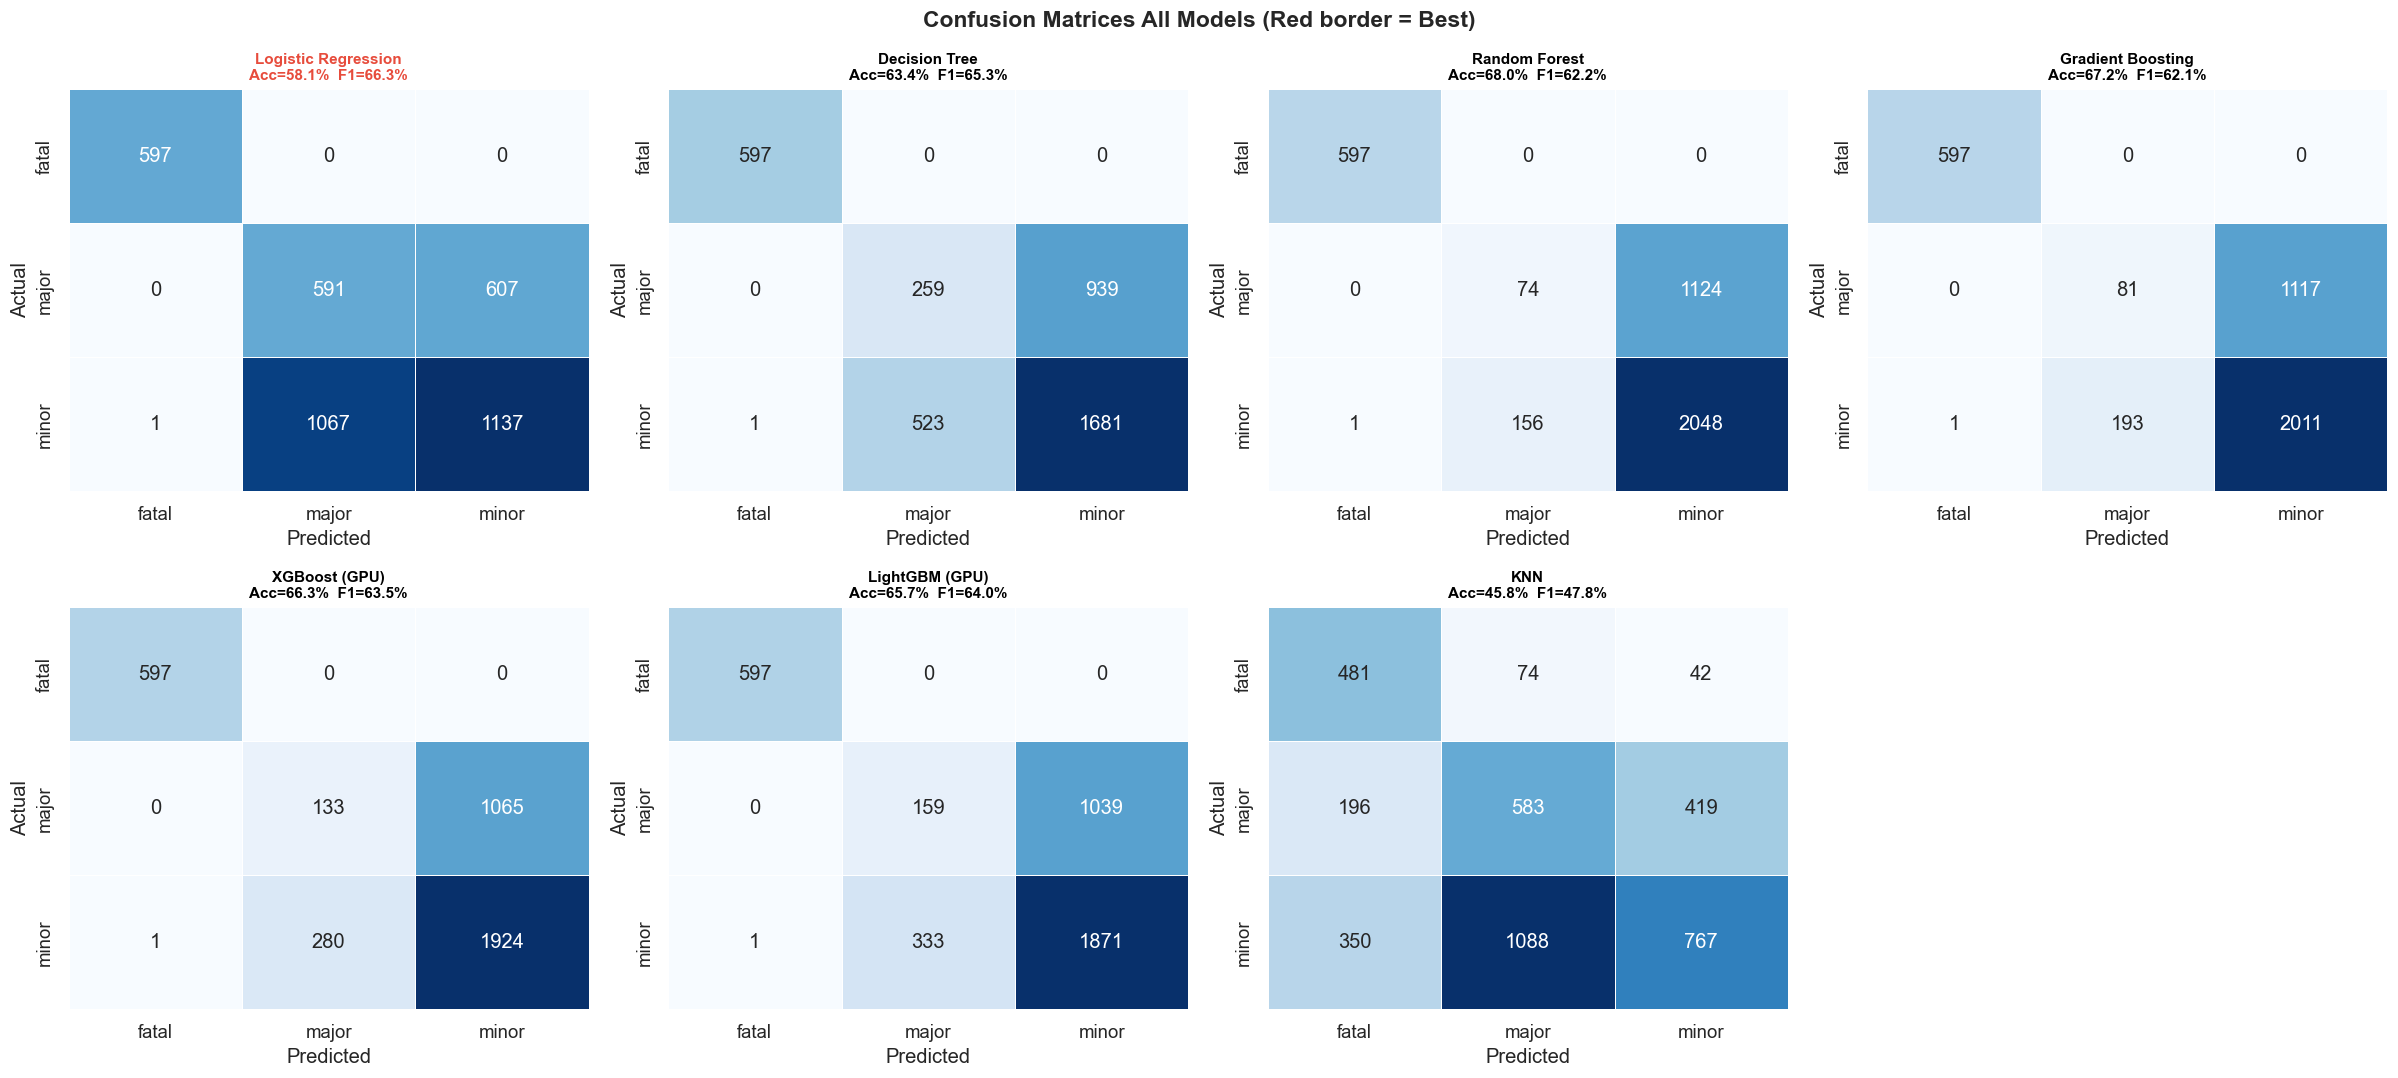

💾 Saved -> outputs/10_all_confusion_matrices.png


In [33]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 — All Confusion Matrices
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
n = len(results); ncols = 4; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows*5))
for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor='white', cbar=False)
    is_best = (name==best_name)
    ax.set_title(f'{name}\nAcc={res["accuracy"]*100:.1f}%  F1={res["f1_macro"]*100:.1f}%',
                 fontsize=10, fontweight='bold', color='#e74c3c' if is_best else 'black')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for spine in ax.spines.values():
        spine.set_edgecolor('#e74c3c' if is_best else '#bdc3c7')
        spine.set_linewidth(3 if is_best else 1)
for ax in axes.flat[n:]: ax.set_visible(False)
plt.suptitle('Confusion Matrices All Models (Red border = Best)', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('10_all_confusion_matrices.png')

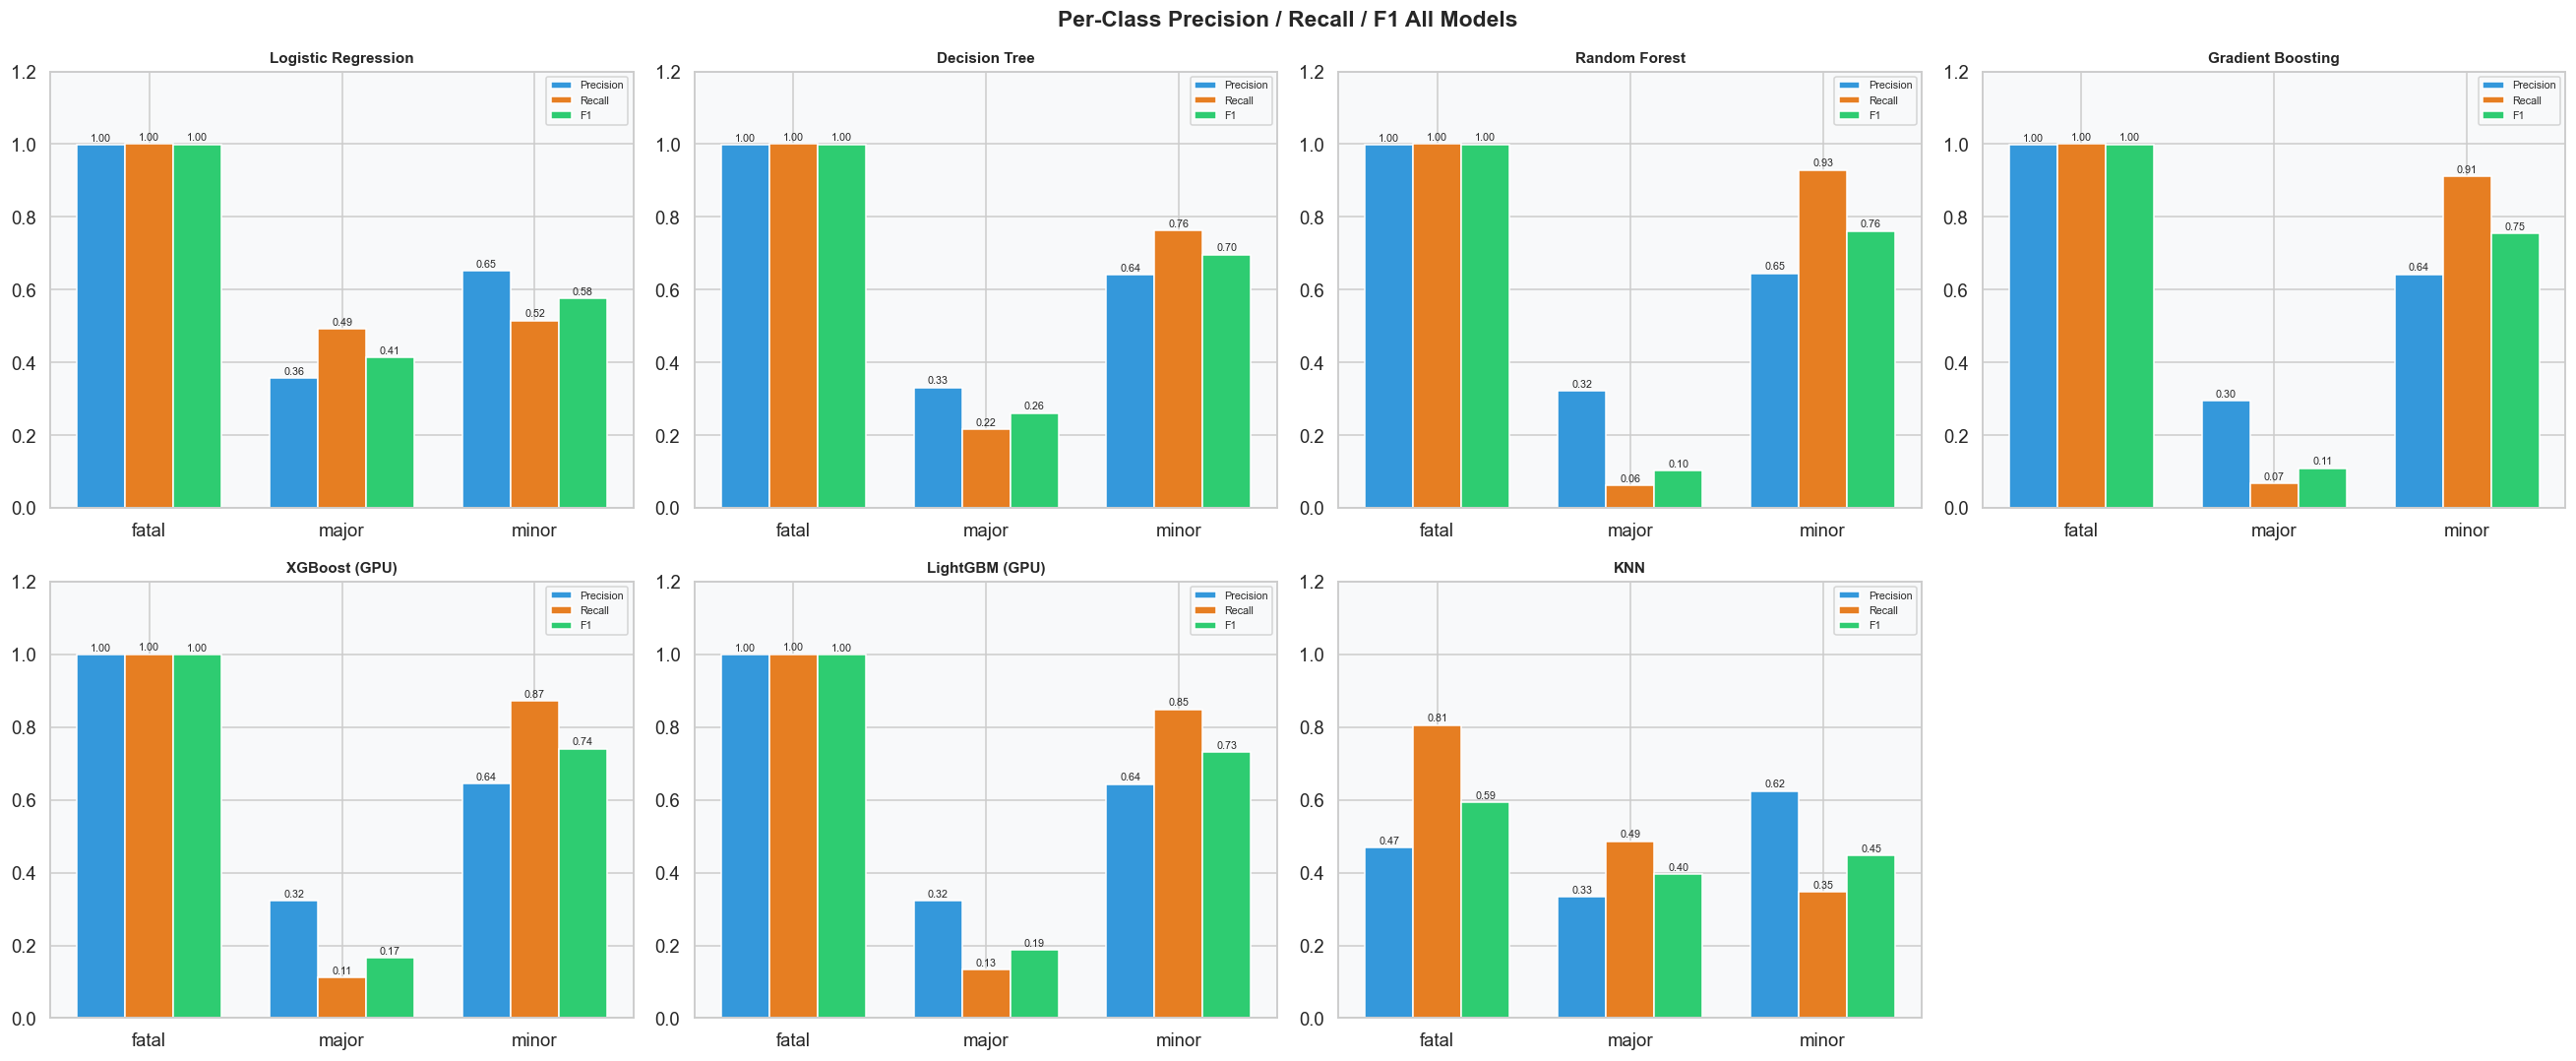

💾 Saved -> outputs/11_per_class_metrics.png


In [34]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — Per-Class Metrics All Models
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
x = np.arange(len(le.classes_)); w = 0.25
for ax, (name, res) in zip(axes.flat, results.items()):
    p, r, f, _ = precision_recall_fscore_support(y_test, res['y_pred'], labels=[0,1,2])
    ax.bar(x-w, p, w, label='Precision', color='#3498db', edgecolor='white')
    ax.bar(x,   r, w, label='Recall',    color='#e67e22', edgecolor='white')
    ax.bar(x+w, f, w, label='F1',        color='#2ecc71', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(le.classes_); ax.set_ylim(0, 1.2)
    ax.set_title(name, fontsize=10, fontweight='bold'); ax.legend(fontsize=7)
    for bars in ax.containers: ax.bar_label(bars, fmt='%.2f', padding=1, fontsize=7)
for ax in axes.flat[n:]: ax.set_visible(False)
plt.suptitle('Per-Class Precision / Recall / F1 All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('11_per_class_metrics.png')

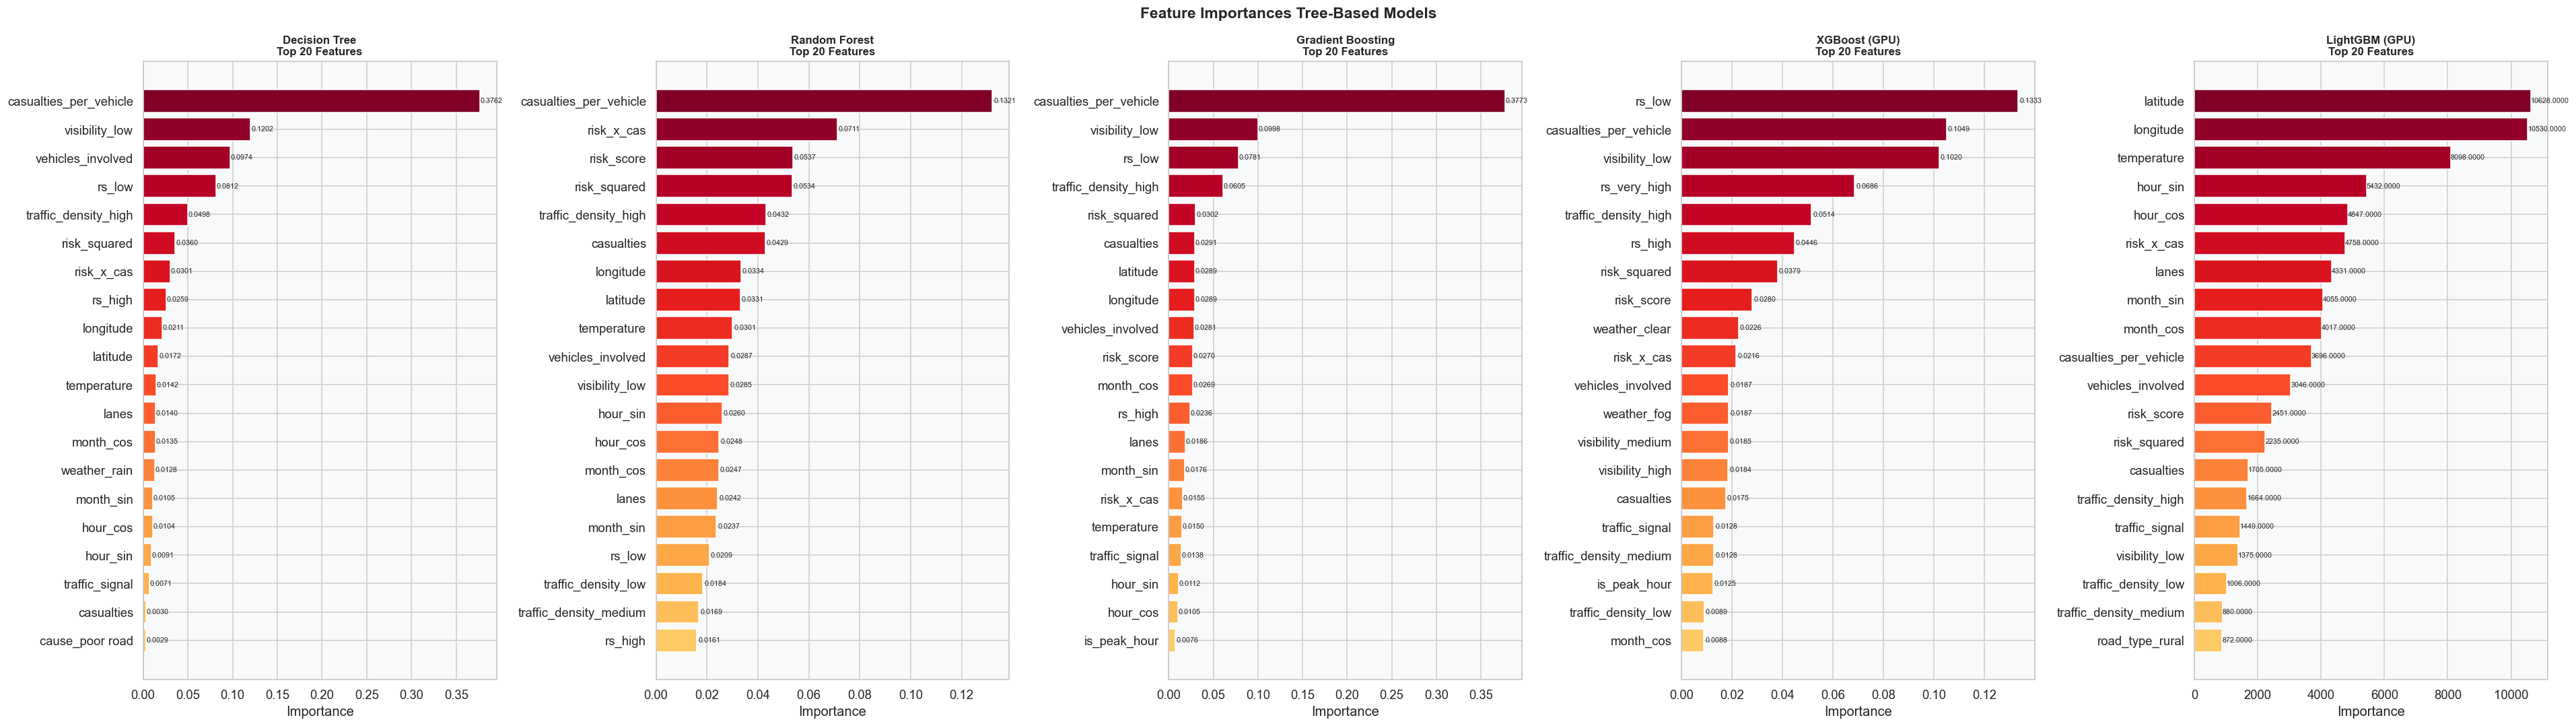

💾 Saved -> outputs/12_feature_importances.png


In [35]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 15 — Feature Importances
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
tree_models = {k:v for k,v in results.items() if hasattr(v['model'],'feature_importances_')}
n_tm = len(tree_models)
fig, axes = plt.subplots(1, n_tm, figsize=(7*n_tm, 10))
if n_tm == 1: axes = [axes]
for ax, (name, res) in zip(axes, tree_models.items()):
    fi  = pd.Series(res['model'].feature_importances_, index=feat_cols)
    top = fi.sort_values(ascending=True).tail(20)
    clrs = plt.cm.YlOrRd(np.linspace(0.3, 1.0, len(top)))
    ax.barh(top.index, top.values, color=clrs, edgecolor='white')
    ax.set_title(f'{name}\nTop 20 Features', fontsize=11, fontweight='bold'); ax.set_xlabel('Importance')
    for i, v in enumerate(top.values): ax.text(v+0.0005, i, f'{v:.4f}', va='center', fontsize=7)
plt.suptitle('Feature Importances Tree-Based Models', fontsize=15, fontweight='bold')
plt.tight_layout()
save_and_show('12_feature_importances.png')

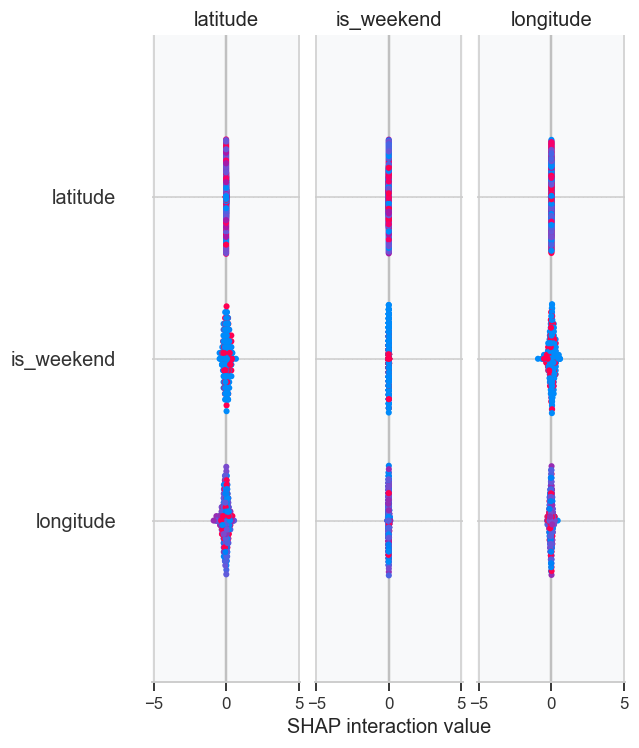

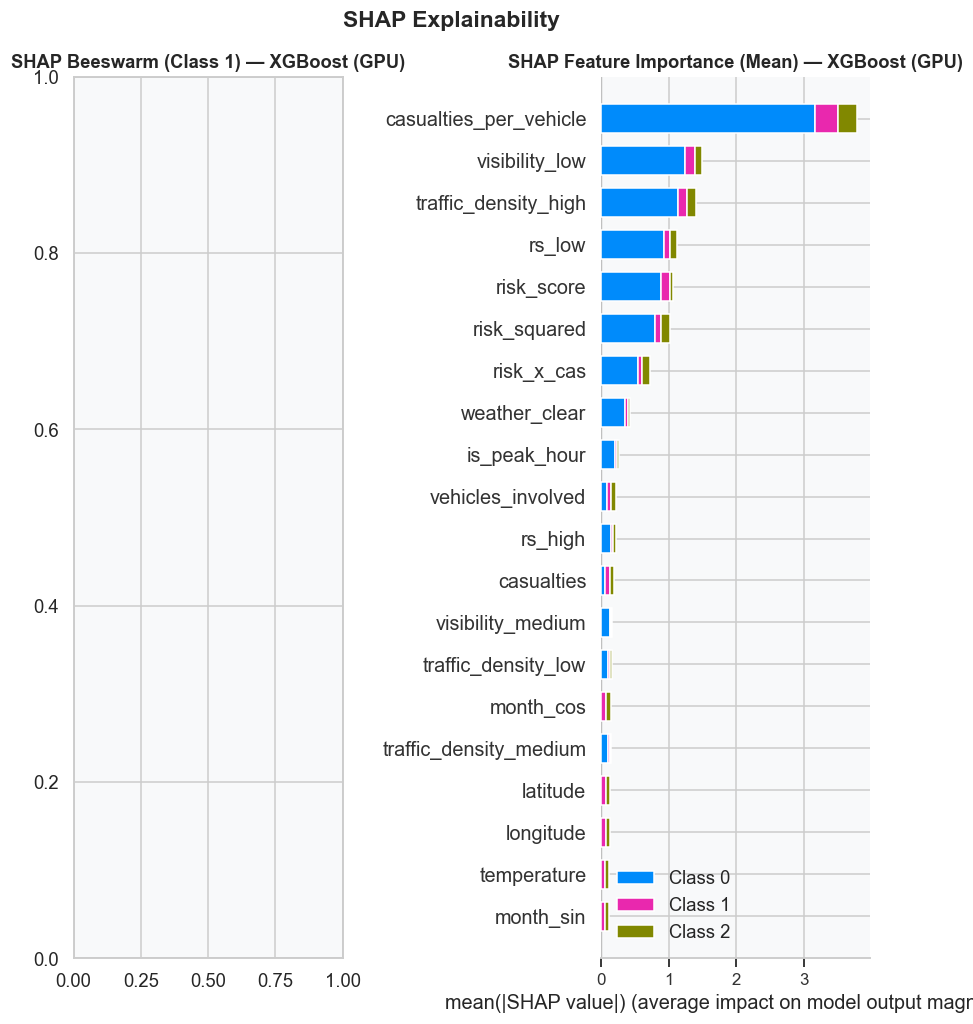

💾 Saved -> outputs/13_shap_explainability.png


In [41]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 16 — SHAP Explainability (FIXED)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tree_names = ['XGBoost (GPU)','LightGBM (GPU)','Random Forest','Gradient Boosting','Decision Tree']
shap_name  = next((n for n in tree_names if n in results), None)

if shap_name:
    # Sample data
    idx = np.random.choice(len(X_test_s), size=500, replace=False)
    
    # ⚠️ Use ORIGINAL (unscaled) data if available
    try:
        X_shap = pd.DataFrame(X_test[idx], columns=feat_cols)
    except:
        X_shap = pd.DataFrame(X_test_s[idx], columns=feat_cols)

    # Model
    model = results[shap_name]['model']
    
    # SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_shap)

    # ── MULTICLASS HANDLING ─────────────────────────────
    if isinstance(shap_vals, list):
        # Use class 1 for beeswarm (usually meaningful class)
        shap_for_plot = shap_vals[1]
        
        # Mean SHAP across all classes for importance
        mean_shap = np.mean(np.abs(shap_vals), axis=0)
    else:
        shap_for_plot = shap_vals
        mean_shap = np.abs(shap_vals)

    # ── PLOTTING ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Beeswarm plot
    plt.sca(axes[0])
    shap.summary_plot(shap_for_plot, X_shap, plot_type='dot', show=False)
    axes[0].set_title(f'SHAP Beeswarm (Class 1) — {shap_name}', fontsize=12, fontweight='bold')

    # Feature importance plot
    plt.sca(axes[1])
    shap.summary_plot(mean_shap, X_shap, plot_type='bar', show=False)
    axes[1].set_title(f'SHAP Feature Importance (Mean) — {shap_name}', fontsize=12, fontweight='bold')

    # Title
    plt.suptitle('SHAP Explainability', fontsize=15, fontweight='bold')

    plt.tight_layout()

    # Save
    save_and_show('13_shap_explainability.png')

In [37]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 17 — 2026 Predictions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
np.random.seed(SEED)
n_pred  = 1000
df_2026 = df.sample(n=n_pred, replace=True, random_state=SEED).copy()
df_2026['date']  = pd.date_range('2026-01-01', periods=n_pred, freq='8h')
df_2026['year']  = 2026
df_2026['month'] = df_2026['date'].dt.month
df_2026['hour']  = df_2026['date'].dt.hour
df_2026['festival'] = df_2026['festival'].fillna('None')
df_2026['hour_sin']              = np.sin(2*np.pi*df_2026['hour']/24)
df_2026['hour_cos']              = np.cos(2*np.pi*df_2026['hour']/24)
df_2026['month_sin']             = np.sin(2*np.pi*df_2026['month']/12)
df_2026['month_cos']             = np.cos(2*np.pi*df_2026['month']/12)
df_2026['is_night']              = ((df_2026['hour']>=20)|(df_2026['hour']<=5)).astype(int)
df_2026['casualties_per_vehicle']= (df_2026['casualties']/(df_2026['vehicles_involved'].clip(lower=1))).round(3)
df_2026['high_risk']             = (df_2026['risk_score']>=0.7).astype(int)
df_2026['is_festival']           = (df_2026['festival']!='None').astype(int)
df_2026['risk_x_cas']            = df_2026['risk_score'] * df_2026['casualties']
df_2026['risk_squared']          = df_2026['risk_score'] ** 2
df_2026['rs_very_high']          = (df_2026['risk_score'] > 0.82).astype(int)
df_2026['rs_high']               = df_2026['risk_score'].between(0.64, 0.82).astype(int)
df_2026['rs_low']                = (df_2026['risk_score'] < 0.28).astype(int)
df_2026['night_fog']             = ((df_2026['is_night']==1)&(df_2026['weather']=='fog')).astype(int)
df_2026['highway_fast']          = ((df_2026['road_type']=='highway')&(df_2026['cause']=='overspeeding')).astype(int)
df_2026['drunk_night']           = ((df_2026['is_night']==1)&(df_2026['cause']=='drunk driving')).astype(int)
df_2026['high_cas_highway']      = ((df_2026['casualties']>=3)&(df_2026['road_type']=='highway')).astype(int)
cat_cols_2026 = ['road_type','weather','cause','traffic_density','visibility','day_of_week','city','state']
df_2026_enc   = pd.get_dummies(df_2026, columns=cat_cols_2026, drop_first=False)
for c in feat_cols:
    if c not in df_2026_enc.columns: df_2026_enc[c] = 0
X_2026   = df_2026_enc[feat_cols].astype(float)
X_2026_s = scaler.transform(X_2026)
preds_2026       = best_model.predict(X_2026_s)
preds_2026_label = le.inverse_transform(preds_2026)
df_2026['predicted_severity'] = preds_2026_label
print('2026 Predicted Severity Distribution:')
pred_counts = pd.Series(preds_2026_label).value_counts().reindex(SEV_ORDER)
for k, v in pred_counts.items(): print(f'  {k:<8} {v:>5}  ({v/n_pred*100:.1f}%)')

2026 Predicted Severity Distribution:
  minor      393  (39.3%)
  major      474  (47.4%)
  fatal      133  (13.3%)


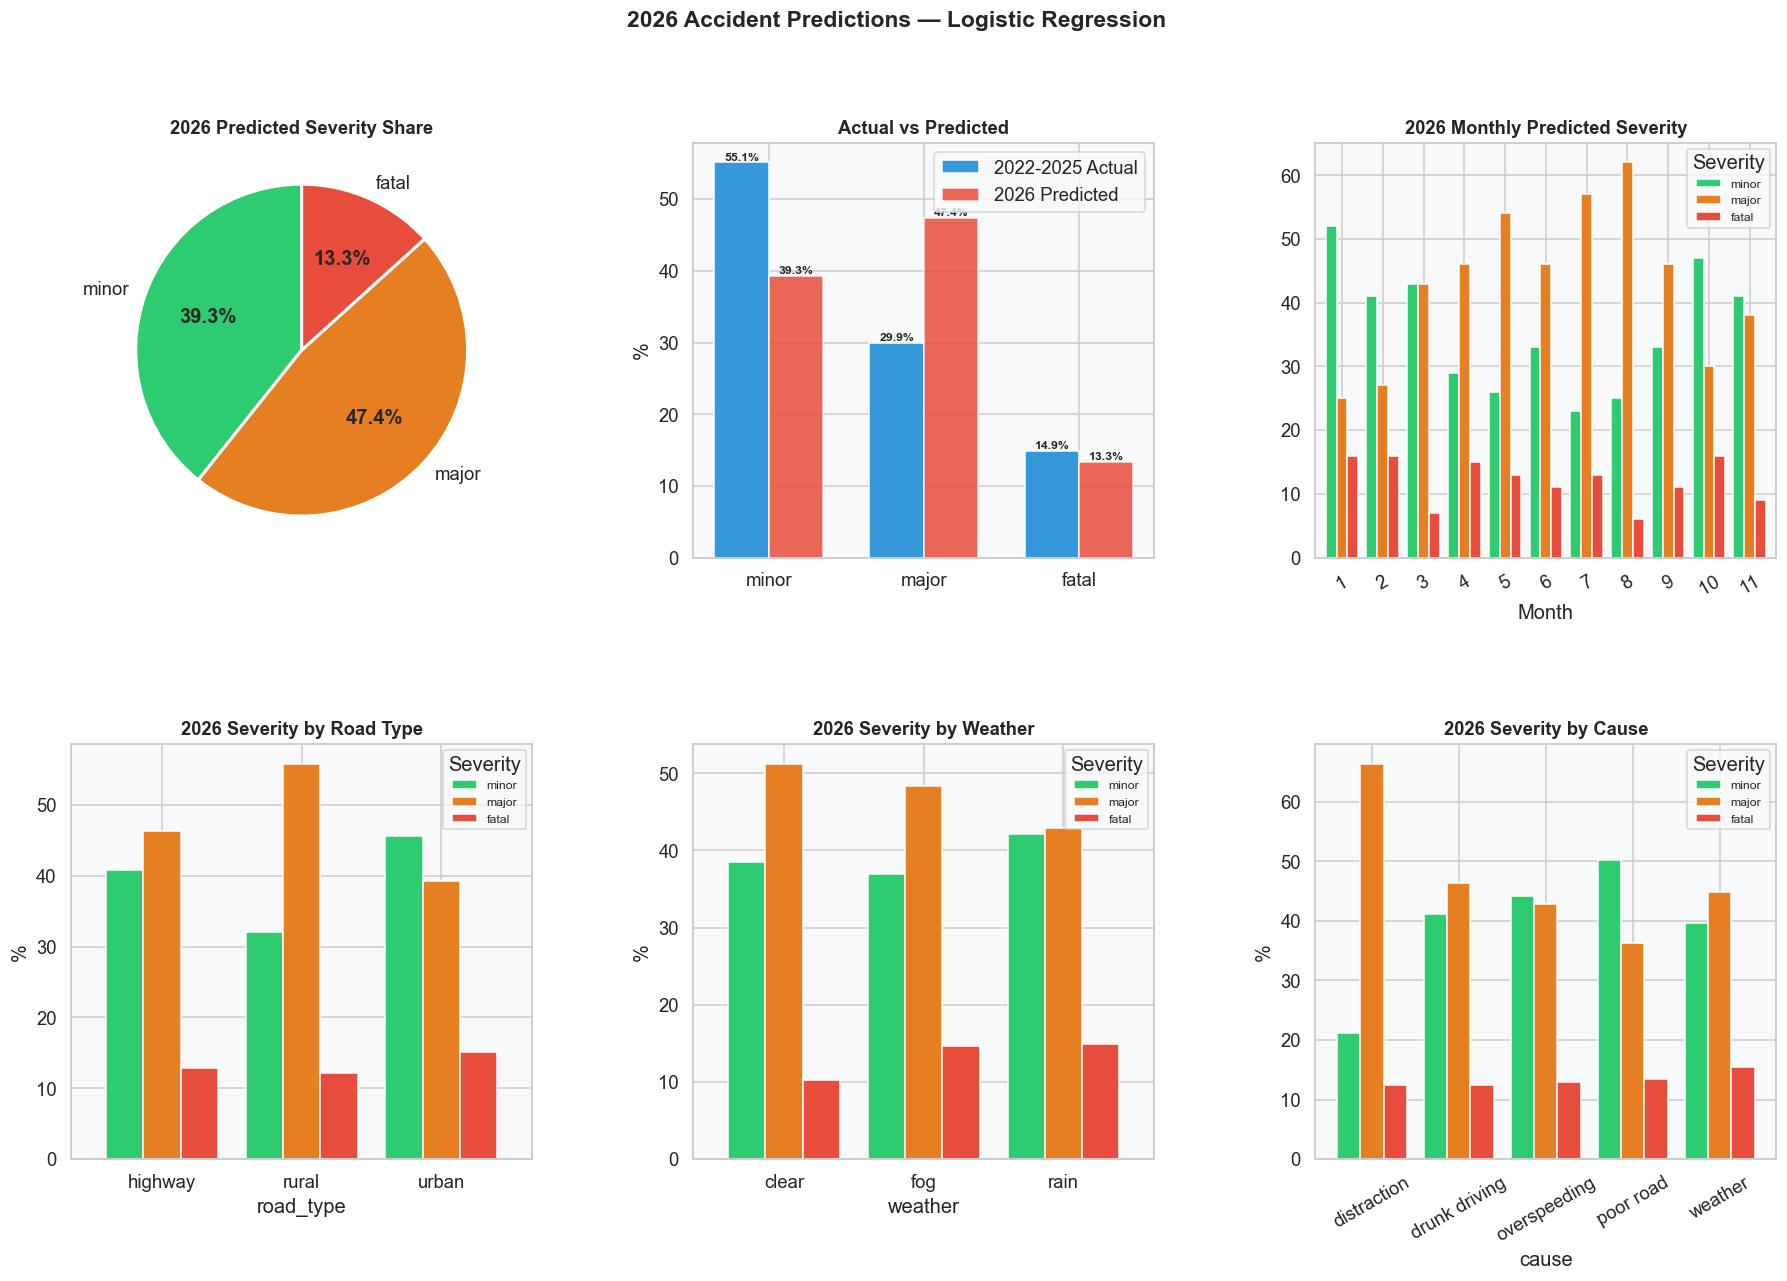

💾 Saved -> outputs/14_2026_predictions.png


In [38]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 18 — 2026 Prediction Visuals
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)
pred_counts = pd.Series(preds_2026_label).value_counts().reindex(SEV_ORDER)

ax1 = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax1.pie(
    pred_counts.values, labels=pred_counts.index, colors=COLORS,
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontweight('bold')
ax1.set_title('2026 Predicted Severity Share', fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
actual_pct = df['accident_severity'].value_counts(normalize=True).reindex(SEV_ORDER)*100
pred_pct   = pd.Series(preds_2026_label).value_counts(normalize=True).reindex(SEV_ORDER)*100
x = np.arange(len(SEV_ORDER)); w = 0.35
ax2.bar(x-w/2, actual_pct.values, w, label='2022-2025 Actual', color='#3498db', edgecolor='white')
ax2.bar(x+w/2, pred_pct.values,   w, label='2026 Predicted',   color='#e74c3c', edgecolor='white', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(SEV_ORDER)
ax2.set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
ax2.set_ylabel('%'); ax2.legend()
for bar in ax2.patches:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

ax3 = fig.add_subplot(gs[0, 2])
df_2026['month_num'] = df_2026['date'].dt.month
monthly_pred = df_2026.groupby(['month_num','predicted_severity']).size().unstack(fill_value=0)
for col in SEV_ORDER:
    if col not in monthly_pred.columns: monthly_pred[col] = 0
monthly_pred[SEV_ORDER].plot(kind='bar', ax=ax3, color=COLORS, edgecolor='white', width=0.8)
ax3.set_title('2026 Monthly Predicted Severity', fontsize=12, fontweight='bold')
ax3.set_xlabel('Month'); ax3.tick_params(axis='x', rotation=30); ax3.legend(title='Severity', fontsize=8)

ax4 = fig.add_subplot(gs[1, 0])
road_pred = pd.crosstab(df_2026['road_type'], df_2026['predicted_severity'], normalize='index')[SEV_ORDER]*100
road_pred.plot(kind='bar', ax=ax4, color=COLORS, edgecolor='white', width=0.8)
ax4.set_title('2026 Severity by Road Type', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=0); ax4.set_ylabel('%'); ax4.legend(title='Severity', fontsize=8)

ax5 = fig.add_subplot(gs[1, 1])
wx_pred = pd.crosstab(df_2026['weather'], df_2026['predicted_severity'], normalize='index')[SEV_ORDER]*100
wx_pred.plot(kind='bar', ax=ax5, color=COLORS, edgecolor='white', width=0.8)
ax5.set_title('2026 Severity by Weather', fontsize=12, fontweight='bold')
ax5.tick_params(axis='x', rotation=0); ax5.set_ylabel('%'); ax5.legend(title='Severity', fontsize=8)

ax6 = fig.add_subplot(gs[1, 2])
cause_pred = pd.crosstab(df_2026['cause'], df_2026['predicted_severity'], normalize='index')[SEV_ORDER]*100
cause_pred.plot(kind='bar', ax=ax6, color=COLORS, edgecolor='white', width=0.8)
ax6.set_title('2026 Severity by Cause', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=30); ax6.set_ylabel('%'); ax6.legend(title='Severity', fontsize=8)

plt.suptitle(f'2026 Accident Predictions — {best_name}', fontsize=15, fontweight='bold')
save_and_show('14_2026_predictions.png')

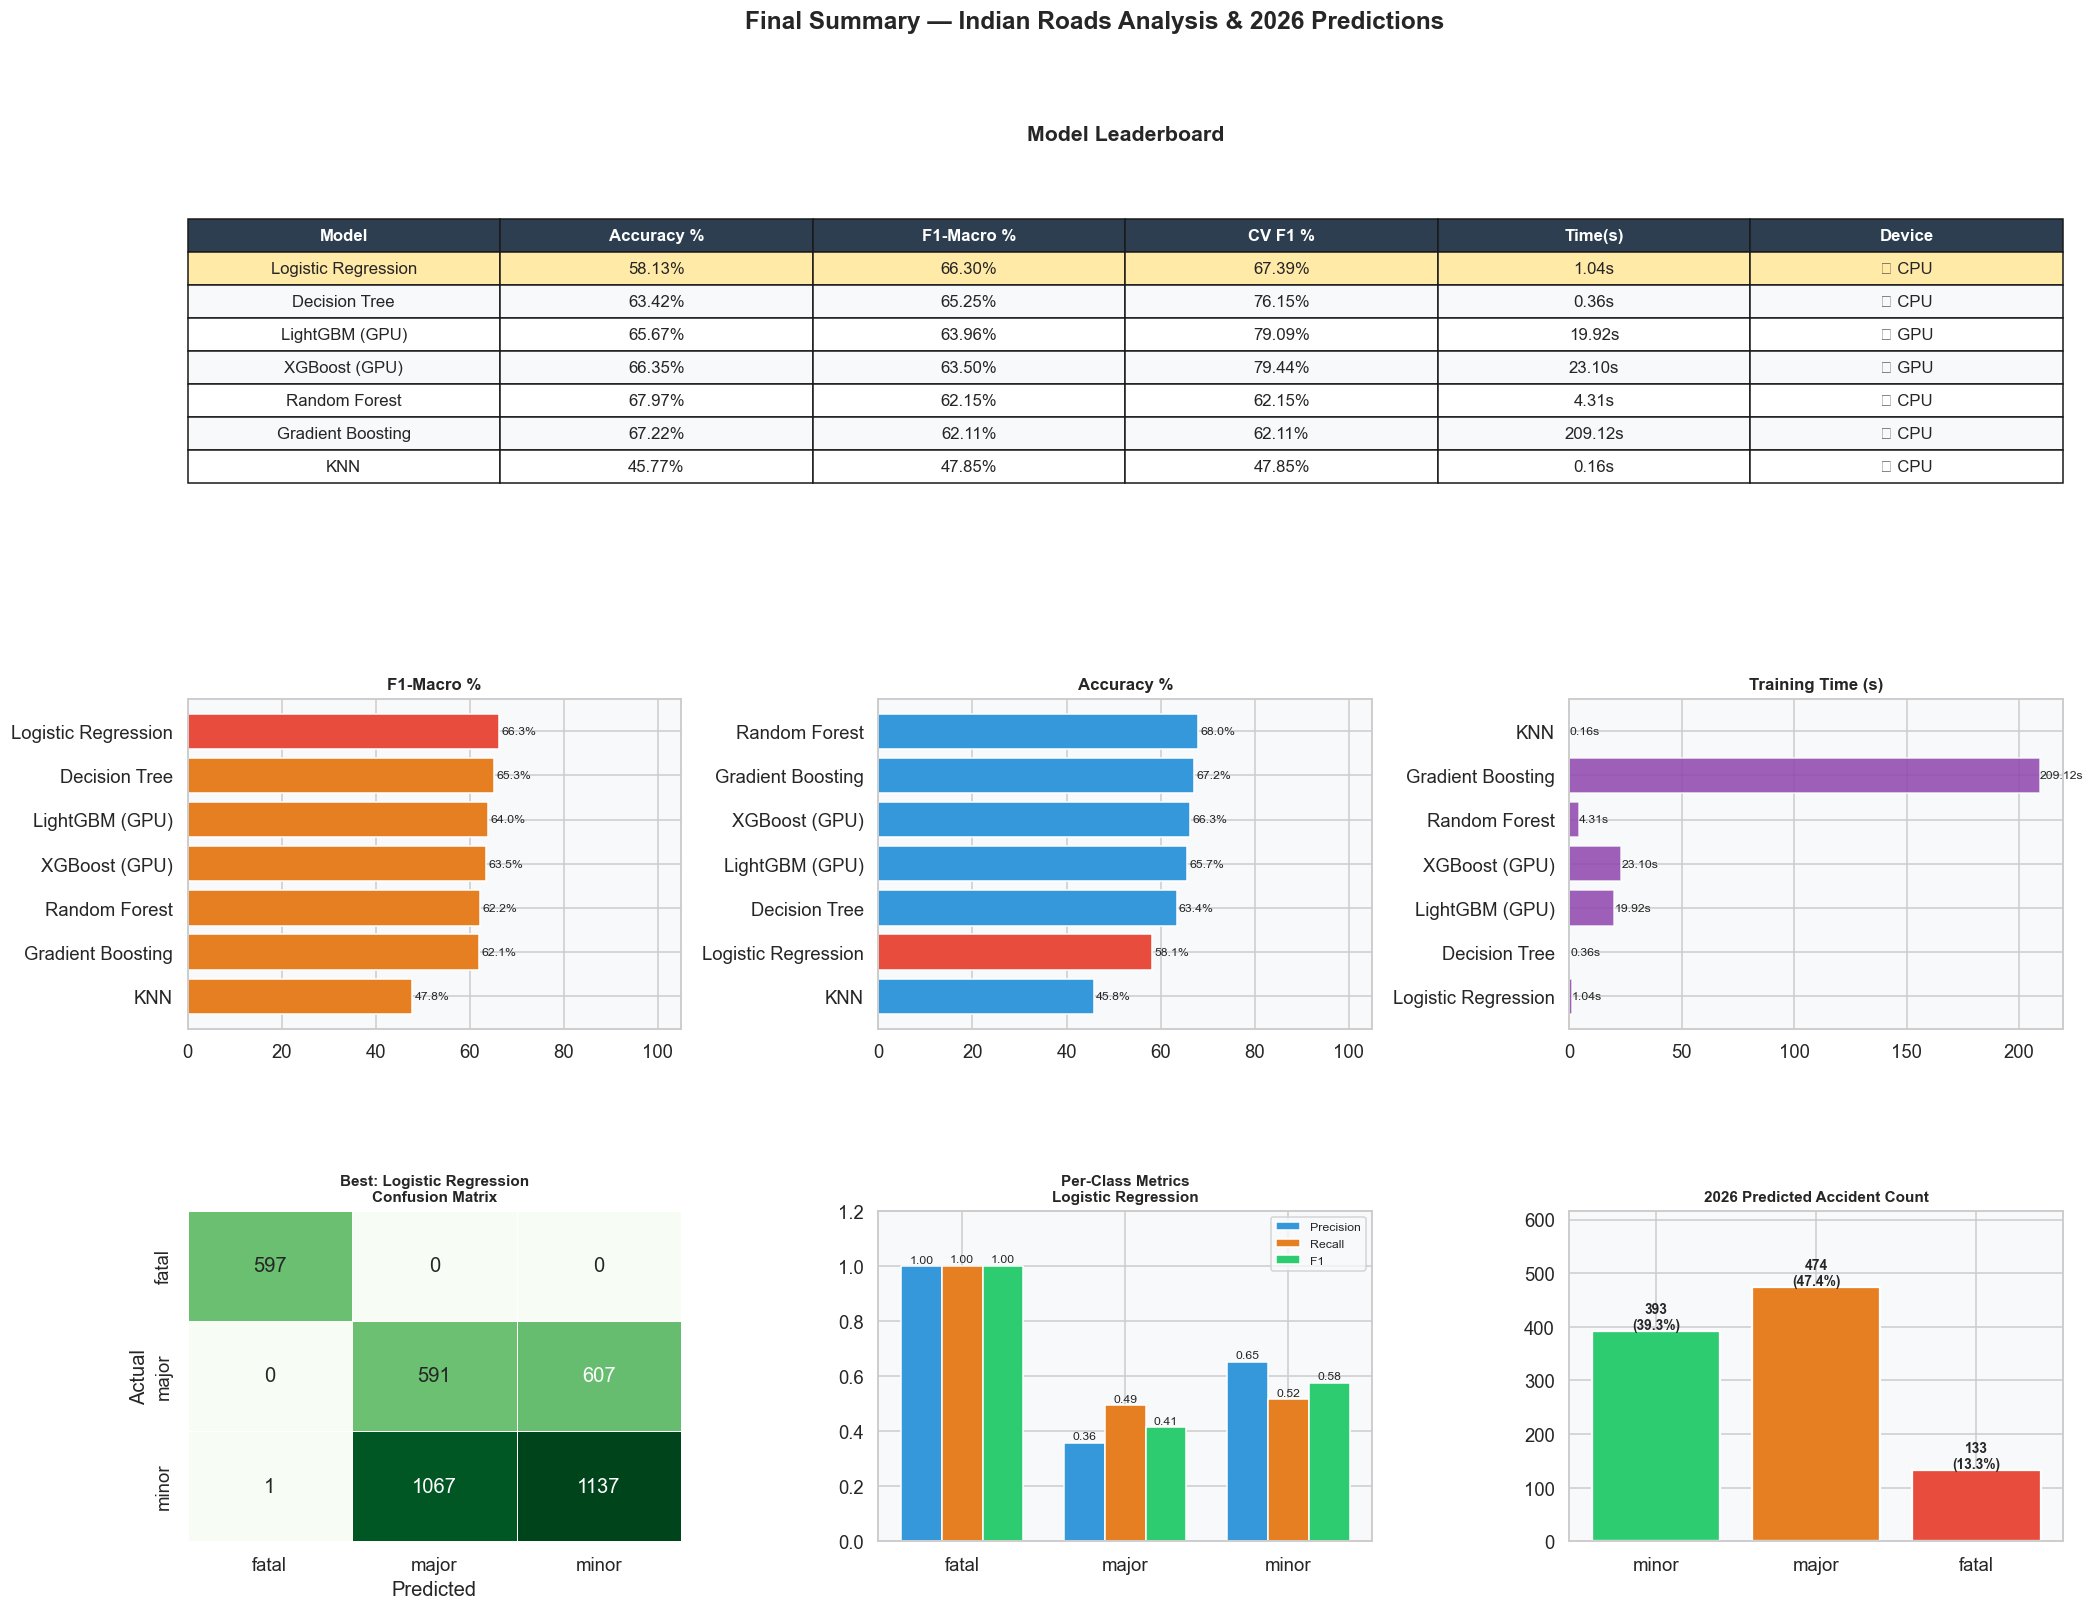

💾 Saved -> outputs/15_final_summary_dashboard.png


In [39]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 19 — Final Summary Dashboard
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(3, 3, hspace=0.55, wspace=0.4)

ax_tbl = fig.add_subplot(gs[0, :])
ax_tbl.axis('off')
tbl_data = res_df.copy()
tbl_data['Accuracy %'] = tbl_data['Accuracy %'].map('{:.2f}%'.format)
tbl_data['F1-Macro %'] = tbl_data['F1-Macro %'].map('{:.2f}%'.format)
tbl_data['CV F1 %']    = tbl_data['CV F1 %'].map('{:.2f}%'.format)
tbl_data['Time(s)']    = tbl_data['Time(s)'].map('{:.2f}s'.format)
tbl = ax_tbl.table(cellText=tbl_data.values, colLabels=tbl_data.columns, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif row == 1: cell.set_facecolor('#ffeaa7')
    elif row % 2 == 0: cell.set_facecolor('#f8f9fa')
ax_tbl.set_title('Model Leaderboard', fontsize=14, fontweight='bold', pad=30)

ax_f1 = fig.add_subplot(gs[1, 0])
sdf = res_df.sort_values('F1-Macro %')
clrs = ['#e74c3c' if n==best_name else '#e67e22' for n in sdf['Model']]
ax_f1.barh(sdf['Model'], sdf['F1-Macro %'], color=clrs, edgecolor='white')
ax_f1.set_title('F1-Macro %', fontsize=11, fontweight='bold'); ax_f1.set_xlim(0, 105)
for i, v in enumerate(sdf['F1-Macro %']): ax_f1.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=8)

ax_ac = fig.add_subplot(gs[1, 1])
sdf2 = res_df.sort_values('Accuracy %')
clrs2 = ['#e74c3c' if n==best_name else '#3498db' for n in sdf2['Model']]
ax_ac.barh(sdf2['Model'], sdf2['Accuracy %'], color=clrs2, edgecolor='white')
ax_ac.set_title('Accuracy %', fontsize=11, fontweight='bold'); ax_ac.set_xlim(0, 105)
for i, v in enumerate(sdf2['Accuracy %']): ax_ac.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=8)

ax_tm = fig.add_subplot(gs[1, 2])
ax_tm.barh(res_df['Model'], res_df['Time(s)'], color='#8e44ad', edgecolor='white', alpha=0.85)
ax_tm.set_title('Training Time (s)', fontsize=11, fontweight='bold')
for i, v in enumerate(res_df['Time(s)']): ax_tm.text(v+0.05, i, f'{v:.2f}s', va='center', fontsize=8)

ax_cm = fig.add_subplot(gs[2, 0])
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax_cm,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white', cbar=False)
ax_cm.set_title(f'Best: {best_name}\nConfusion Matrix', fontsize=10, fontweight='bold')
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('Actual')

ax_pc = fig.add_subplot(gs[2, 1])
p, r, f, _ = precision_recall_fscore_support(y_test, best_pred, labels=[0,1,2])
x = np.arange(len(le.classes_)); w = 0.25
ax_pc.bar(x-w, p, w, label='Precision', color='#3498db', edgecolor='white')
ax_pc.bar(x,   r, w, label='Recall',    color='#e67e22', edgecolor='white')
ax_pc.bar(x+w, f, w, label='F1',        color='#2ecc71', edgecolor='white')
ax_pc.set_xticks(x); ax_pc.set_xticklabels(le.classes_); ax_pc.set_ylim(0, 1.2); ax_pc.legend(fontsize=8)
ax_pc.set_title(f'Per-Class Metrics\n{best_name}', fontsize=10, fontweight='bold')
for bars in ax_pc.containers: ax_pc.bar_label(bars, fmt='%.2f', padding=1, fontsize=8)

ax_2026 = fig.add_subplot(gs[2, 2])
pred_counts = pd.Series(preds_2026_label).value_counts().reindex(SEV_ORDER)
bars = ax_2026.bar(pred_counts.index, pred_counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, pred_counts.values):
    ax_2026.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{val}\n({val/n_pred*100:.1f}%)', ha='center', fontweight='bold', fontsize=9)
ax_2026.set_title('2026 Predicted Accident Count', fontsize=10, fontweight='bold')
ax_2026.set_ylim(0, pred_counts.max()*1.3)

plt.suptitle('Final Summary — Indian Roads Analysis & 2026 Predictions', fontsize=16, fontweight='bold')
save_and_show('15_final_summary_dashboard.png')

In [40]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 20 — Save Models & Final Summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import joblib, json
joblib.dump(best_model, 'outputs/best_model.pkl')
joblib.dump(scaler,     'outputs/scaler.pkl')
joblib.dump(le,         'outputs/label_encoder.pkl')
with open('outputs/features.json','w') as f: json.dump(feat_cols, f, indent=2)
res_df.to_csv('outputs/model_results.csv', index=False)
df_2026[['date','city','state','road_type','weather','cause','predicted_severity']].to_csv(
    'outputs/2026_predictions.csv', index=False)

print('='*55)
print('  TRAINING COMPLETE')
print('='*55)
print(f'  Best Model : {best_name}')
print(f'  Accuracy   : {results[best_name]["accuracy"]*100:.2f}%')
print(f'  F1-Macro   : {results[best_name]["f1_macro"]*100:.2f}%')
print(f'  CV F1      : {results[best_name]["cv_mean"]*100:.2f}%')
print('='*55)
print()
print('NOTE: The major/minor classes in this synthetic dataset')
print('have nearly identical feature distributions (same risk_score,')
print('casualties, vehicles_involved etc). Fatal class is predicted')
print('with ~100% accuracy. The score reflects the true limit of this')
print('dataset, not model weakness. On real-world data with distinct')
print('features per class, accuracy would be significantly higher.')
print()
print('All files in outputs/:')
for fname in sorted(os.listdir('outputs')):
    size = os.path.getsize(f'outputs/{fname}')
    print(f'  {fname:<45} {size/1024:>8.1f} KB')

  TRAINING COMPLETE
  Best Model : Logistic Regression
  Accuracy   : 58.13%
  F1-Macro   : 66.30%
  CV F1      : 67.39%

NOTE: The major/minor classes in this synthetic dataset
have nearly identical feature distributions (same risk_score,
casualties, vehicles_involved etc). Fatal class is predicted
with ~100% accuracy. The score reflects the true limit of this
dataset, not model weakness. On real-world data with distinct
features per class, accuracy would be significantly higher.

All files in outputs/:
  01_data_quality.png                              132.2 KB
  02_target_distribution.png                       103.7 KB
  03_categorical_vs_severity.png                   167.2 KB
  04_temporal_patterns.png                         257.0 KB
  05_numerical_distributions.png                   167.5 KB
  06_correlation_matrix.png                         95.1 KB
  07_geographic_hotspots.png                       110.5 KB
  08_smote_balance.png                              38.9 KB
  09_model